# NovaPay Fraudulent Transaction Detection

## Week 1 — Day 1: Foundations and Initial Setup

**Task:** Week 1: Foundations & Initial Setup  
**Project Duration:** 10 Days  
**Project Type:** Supervised Binary Classification  
**Target Variable:** `is_fraud`

---

### Day 1 Aim

The aim of Day 1 is to understand the business problem, define the project objectives and success criteria, identify the main stakeholders, and confirm that the dataset can be loaded successfully.

## 1. What Problem Are My Solving?

NovaPay is a digital money-transfer company that allows customers to send, receive and hold money across different countries.

The company faces fraud risks such as:

- identity theft;
- account takeover;
- unauthorised payments;
- transaction laundering.

NovaPay currently uses fixed fraud rules and manual reviews. These methods may miss new fraud patterns and may also flag genuine customers incorrectly.

Therefore, the business needs a machine-learning system that can identify suspicious transactions more effectively.

## 2. Project Objective

The main objective is to build a machine-learning model that can classify each transaction as either legitimate or fraudulent.

The target column is `is_fraud`:

- `0` means a legitimate transaction.
- `1` means a fraudulent transaction.

The project also aims to:

- improve fraud recall by at least 15% compared with the existing rules-based baseline;
- maintain acceptable precision so that fewer genuine customers are wrongly flagged;
- explain why a transaction is predicted as fraud;
- prepare the model for real-time transaction scoring.

## 3. Machine-Learning Problem

This is a **supervised binary classification** problem.

It is **supervised** because the dataset contains known fraud labels that the model can learn from.

It is **binary classification** because the model predicts one of two classes:

- legitimate transaction;
- fraudulent transaction.

## 4. Success Criteria

The model will mainly be evaluated using:

- **Recall:** how many actual fraudulent transactions the model correctly detects.
- **Precision:** how many transactions predicted as fraud are truly fraudulent.
- **F1-score:** the balance between recall and precision.
- **ROC-AUC:** how well the model separates fraudulent and legitimate transactions.

Accuracy will also be checked, but it will not be used alone because fraud datasets are usually imbalanced.

### Business Meaning

High recall helps NovaPay reduce missed fraud and financial loss.

High precision helps NovaPay avoid delaying genuine customers and reduces unnecessary manual reviews.

## 5. Main Stakeholders

### Fraud Analysts
They need accurate fraud alerts and fewer unnecessary manual reviews.

### Customers
They expect safe and fast transfers without incorrect fraud blocks.

### Compliance and Regulatory Teams
They need fraud decisions to be clear, explainable and auditable.

### Business Management
Management wants to reduce fraud losses, chargebacks and compliance penalties.

### Data Science and Engineering Teams
They are responsible for building, testing, deploying and maintaining the system.

## 6. Project Scope

This project will include:

- data assessment;
- data cleaning and preparation;
- feature engineering and exploratory data analysis;
- baseline and advanced machine-learning models;
- class-imbalance handling;
- model evaluation and explainability;
- API packaging;
- monitoring, drift detection and a retraining plan;
- final report, slides and handover.

## 7. Assumptions, Risks and Constraints

### Assumptions

- The `is_fraud` column contains reliable fraud labels.
- Historical transaction patterns can help predict future fraud.
- The available customer, transaction and device information is useful for fraud detection.

### Risks

- Missing or incorrect data.
- A large difference between the number of legitimate and fraudulent transactions.
- False positives that affect genuine customers.
- False negatives that allow fraud to go undetected.
- Fraud patterns changing over time.

### Constraints

- The project must be completed within 10 days.
- The final model should support real-time scoring.
- Fraud predictions should be explainable.
- Recall should improve by at least 15% compared with the rules-based baseline.

# Initial Project Setup

## 8. Import the Basic Libraries

### What problem are my solving?

Before working with the dataset, the Python libraries needed for data analysis must be imported.

- `pandas` is used to work with tables and datasets.
- `numpy` supports numerical operations.
- `matplotlib` is used for charts later in the project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


## 9. Load the NovaPay Dataset

### What problem are my solving?

The Excel file must be loaded into Python so that it can be examined and prepared during the remaining project days.

In [2]:
file_name = "nova_pay_combined (1).xlsx"

df = pd.read_excel(file_name)

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 10. Confirm the Dataset Setup

This is only a basic setup check. The detailed data-quality assessment will be completed on Day 2.

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Target column available:", "is_fraud" in df.columns)

Number of rows: 11400
Number of columns: 26
Target column available: True


## 11. Preview the Dataset

Displaying the first five rows confirms that the dataset was imported correctly.

In [4]:
df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


# Day 1 Summary and Business Decision

## What Was Completed Today?

- The NovaPay business problem was defined.
- The project objective and machine-learning problem were identified.
- The success criteria and evaluation metrics were explained.
- The main stakeholders were identified.
- The project scope, assumptions, risks and constraints were recorded.
- The required Python libraries were imported.
- The NovaPay dataset was loaded successfully.
- The dataset was confirmed to contain **11,400 rows**, **26 columns** and the target variable `is_fraud`.

## Day 1 Business Decision

The dataset contains the required fraud target, so the project can proceed as a supervised binary-classification task.

The next step is to complete a detailed data assessment on Day 2 before cleaning or modelling begins.

# Day 1 Deliverable

The official Day 1 deliverable is:

**`01_kickoff_summary.md`**

It contains:

- the company background;
- the business problem;
- the project objective;
- the machine-learning problem;
- the success criteria;
- the stakeholders;
- the project scope;
- the assumptions, risks and constraints;
- the expected outcome;
- the Day 1 setup result.

## Personal Learning Reflection

Today, I learned that a machine-learning project should begin with a clear business problem before any model is built. I also learned why recall and precision are both important in fraud detection. Finally, I successfully imported the required libraries and loaded the NovaPay dataset.

# WEEK 1 – DAY 2

## Data Sources & Initial Assessment

### Objective

To understand the available NovaPay transaction data, fraud-label distribution, data-quality problems and limitations before cleaning or modelling.

### Tasks / Activities

- Explore the raw transaction dataset and its metadata fields.
- Check the confirmed fraud labels and customer chargeback history.
- Identify missing values, duplicate records and incorrect data types.
- Examine whether the fraud classes are balanced or imbalanced.
- Document the main data-quality issues and dataset limitations.

### Research

Bias and fairness in financial machine-learning systems.

### Expected Output

A data-assessment report named `02_data_assessment.md`, summarising the data scope, fraud-label distribution, data-quality problems, class imbalance and limitations.

# WEEK 1 – DAY 2

## Data Sources & Initial Assessment

### Objective

To understand the available NovaPay transaction data, fraud labels, data-quality problems and dataset limitations before cleaning or building a machine-learning model.

## Reload the Dataset After Kernel Restart

The dataset was assessed initially during Day 1. It is being reloaded because the Jupyter kernel restarted and the `df` variable was no longer available.

In [6]:
import pandas as pd

df = pd.read_excel("nova_pay_combined (1).xlsx")

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 1. Examine the Fraud-Label Distribution

### What question are my answering?

I want to find out how many transactions are legitimate and how many are fraudulent.

This is important because a large difference between the two groups may cause a machine-learning model to favour the majority class and overlook fraudulent transactions.

In [18]:
fraud_counts = df["is_fraud"].value_counts().sort_index()

fraud_percentages = (
    df["is_fraud"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("Number of transactions:")
print(fraud_counts)

print("\nPercentage of transactions:")
print(fraud_percentages)

Number of transactions:
is_fraud
0    10403
1      997
Name: count, dtype: int64

Percentage of transactions:
is_fraud
0    91.25
1     8.75
Name: proportion, dtype: float64


### Observation

The dataset contains 10,403 legitimate transactions and 997 fraudulent transactions.

Legitimate transactions represent 91.25% of the dataset, while fraudulent transactions represent 8.75%.

This shows that the dataset is imbalanced because legitimate transactions are much more common than fraudulent transactions. This imbalance is important because a machine-learning model may focus more on the majority class and fail to detect enough fraud cases.

## 2. Examine Chargeback History and Fraud

### What question are my answering?

I want to find out whether transactions linked to customers with previous chargebacks are more likely to be fraudulent.

This is important because chargeback history may be a useful warning sign when detecting fraud.

In [8]:
chargeback_summary = pd.crosstab(
    df["chargeback_history_count"],
    df["is_fraud"]
)

chargeback_summary.columns = ["Legitimate", "Fraud"]

chargeback_summary["Total"] = (
    chargeback_summary["Legitimate"]
    + chargeback_summary["Fraud"]
)

chargeback_summary["Fraud Rate (%)"] = (
    chargeback_summary["Fraud"]
    / chargeback_summary["Total"]
    * 100
).round(2)

chargeback_summary

,Legitimate,Fraud,Total,Fraud Rate (%)
chargeback_history_count,,,,
0,10378,580,10958,5.29
1,24,307,331,92.75
2,1,110,111,99.10


### Observation

The results show a strong relationship between previous chargebacks and fraud.

For transactions with no previous chargeback, 5.29% were fraudulent.

For transactions with one previous chargeback, 92.75% were fraudulent.

For transactions with two previous chargebacks, 99.10% were fraudulent.

This suggests that `chargeback_history_count` may be an important feature for detecting fraud.

However, NovaPay must confirm that the chargeback history was already available before the transaction was classified. If the information was added after fraud was confirmed, using it in the model could cause data leakage.

## 3. Assess Missing Values

### What question are am answering?

I want to identify which columns contain missing information and measure how much data is missing.

This is important because missing values can affect analysis and machine-learning performance if they are not handled correctly.

In [9]:
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": (
        missing_values / len(df) * 100
    ).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
]

missing_summary

,Missing Values,Percentage (%)
timestamp,29,0.25
amount_usd,305,2.68
fee,295,2.59
ip_address,305,2.68
ip_country,302,2.65
kyc_tier,302,2.65
device_trust_score,295,2.59


### Observation

Seven columns contain missing values.

- `timestamp` has 29 missing values, representing 0.25%.
- `amount_usd` has 305 missing values, representing 2.68%.
- `fee` has 295 missing values, representing 2.59%.
- `ip_address` has 305 missing values, representing 2.68%.
- `ip_country` has 302 missing values, representing 2.65%.
- `kyc_tier` has 302 missing values, representing 2.65%.
- `device_trust_score` has 295 missing values, representing 2.59%.

The amount of missing data is relatively small, but these values still need to be handled before modelling.

No missing values will be removed or replaced during Day 2 because data cleaning will be completed on Day 3.

## 4. Check for Duplicate Transactions

### What question are my answering?

I want to find out whether the same transaction appears more than once in the dataset.

Duplicate transactions can distort the analysis because the same transaction may be counted repeatedly. They can also affect the machine-learning model by giving repeated records too much influence.

In [10]:
duplicate_rows = df.duplicated().sum()
unique_transaction_ids = df["transaction_id"].nunique()

print("Total rows:", len(df))
print("Exact duplicate rows:", duplicate_rows)
print("Unique transaction IDs:", unique_transaction_ids)

Total rows: 11400
Exact duplicate rows: 200
Unique transaction IDs: 11200


### Observation

The dataset contains 11,400 rows but only 11,200 unique transaction IDs.

There are 200 exact duplicate rows, meaning some transactions appear more than once in the dataset.

Duplicate records can distort the analysis and may cause the machine-learning model to give repeated transactions too much importance.

The duplicate rows will be removed during Day 3 when the data-cleaning process begins.

## 5. Check Categorical Data Quality

### What question am I answering?

I want to check whether categories such as transaction channel and KYC tier are written consistently.

Spelling mistakes and differences in capital letters may cause the same category to be treated as several different categories.

In [11]:
print("Transaction channels:")
print(df["channel"].value_counts(dropna=False))

print("\nKYC tiers:")
print(df["kyc_tier"].value_counts(dropna=False))

Transaction channels:
channel
mobile     6414
web        3761
ATM        1012
mobille      60
MOBILE       47
unknown      37
WEB          36
weeb         24
ATm           9
Name: count, dtype: int64

KYC tiers:
kyc_tier
standard    7996
enhanced    1846
low         1047
NaN          302
standrd       72
STANDARD      70
unknown       32
ENHANCED      17
enhancd       12
LOW            5
NAN            1
Name: count, dtype: int64


### Observation

The `channel` and `kyc_tier` columns contain spelling mistakes, inconsistent capital letters and placeholder values.

Examples from the `channel` column include:

- `mobile`, `MOBILE` and `mobille`
- `web`, `WEB` and `weeb`
- `ATM` and `ATm`
- `unknown`

Examples from the `kyc_tier` column include:

- `standard`, `STANDARD` and `standrd`
- `enhanced`, `ENHANCED` and `enhancd`
- `low` and `LOW`
- `unknown`
- `NAN`
- 302 actual missing values shown as `NaN`

These variations may refer to the same categories, but Python currently treats them as different values.

They will be corrected and standardised during Day 3. No category values will be changed during the Day 2 assessment.

## 6. Check Numerical Data Quality

### What question are my answering?

I want to identify numerical values that may be incorrect, impossible or unusually high.

Values such as negative transaction counts or risk scores above their expected range may be data-entry errors and could affect the machine-learning model.

In [12]:
numerical_range_check = df[
    [
        "fee",
        "ip_risk_score",
        "device_trust_score",
        "txn_velocity_1h",
        "txn_velocity_24h"
    ]
].agg(["min", "max"])

numerical_range_check

,fee,ip_risk_score,device_trust_score,txn_velocity_1h,txn_velocity_24h
min,-1.00,0.004,-0.100,-1,0
max,9999.99,1.200,0.999,8,11


### Observation

The numerical range check identified several values that may be incorrect or unrealistic.

- `fee` has a minimum value of -1.00. A transaction fee would not normally be negative.
- `fee` has a maximum value of 9,999.99, which appears unusually high and may be an outlier or data-entry error.
- `ip_risk_score` has a maximum value of 1.20. If this score is expected to range from 0 to 1, this value is outside the expected range.
- `device_trust_score` has a minimum value of -0.10. If this score is expected to range from 0 to 1, the negative value is invalid.
- `txn_velocity_1h` has a minimum value of -1. A transaction count should not normally be negative.
- `txn_velocity_24h` ranges from 0 to 11, which appears reasonable based on the current dataset.

These suspicious values will not be changed during Day 2. They will be investigated and handled during the Day 3 data-cleaning process.

## 7. Explore Transaction Data and Metadata Fields

### What question are my answering?

I want to understand the types of information available in the NovaPay dataset.

This is important because fraud detection depends on transaction, customer, device, location and risk information.

In [13]:
print("Total number of columns:", len(df.columns))

for column in df.columns:
    print(column)

Total number of columns: 26
transaction_id
customer_id
timestamp
home_country
source_currency
dest_currency
channel
amount_src
amount_usd
fee
exchange_rate_src_to_dest
device_id
new_device
ip_address
ip_country
location_mismatch
ip_risk_score
kyc_tier
account_age_days
device_trust_score
chargeback_history_count
risk_score_internal
txn_velocity_1h
txn_velocity_24h
corridor_risk
is_fraud


### Observation

The NovaPay dataset contains 26 columns covering different types of information.

#### Transaction Information

- `transaction_id`
- `timestamp`
- `source_currency`
- `dest_currency`
- `channel`
- `amount_src`
- `amount_usd`
- `fee`
- `exchange_rate_src_to_dest`

#### Customer Information

- `customer_id`
- `home_country`
- `kyc_tier`
- `account_age_days`
- `chargeback_history_count`

#### Device and Location Information

- `device_id`
- `new_device`
- `ip_address`
- `ip_country`
- `location_mismatch`
- `device_trust_score`

#### Risk and Behaviour Information

- `ip_risk_score`
- `risk_score_internal`
- `txn_velocity_1h`
- `txn_velocity_24h`
- `corridor_risk`

#### Fraud Label

- `is_fraud`

These fields provide information about the transaction, customer, device, location, previous behaviour and risk level.

The `is_fraud` column is the target variable used to identify whether a transaction is legitimate or fraudulent.

## 8. Investigate a Potential Bias Source: Geography

### What question are my answering?

I want to examine whether fraud labels are distributed differently across customers from different home countries.

Geography may help identify unusual transaction patterns, but it could also create unfair predictions if the model learns to treat customers from a particular country as suspicious simply because of their location.

In [14]:
country_fraud_summary = (
    df.groupby("home_country")["is_fraud"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

country_fraud_summary.columns = [
    "Home Country",
    "Total Transactions",
    "Fraud Transactions",
    "Fraud Rate"
]

country_fraud_summary["Fraud Rate (%)"] = (
    country_fraud_summary["Fraud Rate"] * 100
).round(2)

country_fraud_summary[
    [
        "Home Country",
        "Total Transactions",
        "Fraud Transactions",
        "Fraud Rate (%)"
    ]
].sort_values(
    "Fraud Rate (%)",
    ascending=False
)

,Home Country,Total Transactions,Fraud Transactions,Fraud Rate (%)
0,CA,1228,185,15.07
1,UK,2132,282,13.23
2,US,8008,529,6.61
3,unknown,32,1,3.12


### Observation

The fraud rate differs across the customer home countries in the dataset.

- Canada has 1,228 transactions, with 185 labelled as fraud, giving a fraud rate of 15.07%.
- The United Kingdom has 2,132 transactions, with 282 labelled as fraud, giving a fraud rate of 13.23%.
- The United States has 8,008 transactions, with 529 labelled as fraud, giving a fraud rate of 6.61%.
- The `unknown` category has 32 transactions, with 1 labelled as fraud, giving a fraud rate of 3.12%.

These differences show that geography could influence the model.

However, a higher fraud rate for a country does not prove that customers from that country are naturally more fraudulent. The difference may be caused by sample size, transaction behaviour, previous investigation practices or bias in the historical fraud labels.

NovaPay should therefore use geographical information carefully and monitor whether the model unfairly flags customers from particular countries.

## 9. Investigate a Potential Bias Source: KYC Completeness

### What question are we answering?

We want to examine whether fraud rates differ across KYC tiers and whether transactions with missing KYC information are labelled differently.

KYC information may help NovaPay understand customer risk, but incomplete KYC records could cause the model to unfairly treat some customers as more suspicious.

In [15]:
kyc_fraud_summary = (
    df.assign(
        kyc_group=df["kyc_tier"].fillna("Missing")
    )
    .groupby("kyc_group")["is_fraud"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

kyc_fraud_summary.columns = [
    "KYC Tier",
    "Total Transactions",
    "Fraud Transactions",
    "Fraud Rate"
]

kyc_fraud_summary["Fraud Rate (%)"] = (
    kyc_fraud_summary["Fraud Rate"] * 100
).round(2)

kyc_fraud_summary[
    [
        "KYC Tier",
        "Total Transactions",
        "Fraud Transactions",
        "Fraud Rate (%)"
    ]
].sort_values(
    "Fraud Rate (%)",
    ascending=False
)

,KYC Tier,Total Transactions,Fraud Transactions,Fraud Rate (%)
7,low,1047,536,51.19
8,standard,7996,409,5.12
10,unknown,32,1,3.12
2,Missing,302,8,2.65
6,enhanced,1846,41,2.22
4,STANDARD,70,1,1.43
9,standrd,72,1,1.39
1,LOW,5,0,0.00
0,ENHANCED,17,0,0.00
5,enhancd,12,0,0.00


### Observation

The KYC results show that fraud rates differ across KYC groups.

- The `low` KYC tier has 1,047 transactions, with 536 labelled as fraud, giving a fraud rate of 51.19%.
- The `standard` tier has 7,996 transactions, with 409 labelled as fraud, giving a fraud rate of 5.12%.
- The `enhanced` tier has 1,846 transactions, with 41 labelled as fraud, giving a fraud rate of 2.22%.
- Transactions with missing KYC information have a fraud rate of 2.65%.
- The `unknown` category has a fraud rate of 3.12%.

The `low` KYC tier has a much higher fraud rate than the other main tiers, so it may be an important fraud indicator.

However, the KYC column also contains inconsistent labels such as `low` and `LOW`, `standard`, `STANDARD` and `standrd`, and `enhanced`, `ENHANCED` and `enhancd`.

These inconsistencies split the same category into separate groups and could distort the analysis. The labels must be standardised during Day 3 before drawing final conclusions.

NovaPay should also use KYC information carefully because incomplete or lower KYC status could cause some customers to be flagged more often. Model performance should be monitored to ensure that KYC-related decisions do not create unfair treatment.

## 10. Bias and Fairness in Financial Machine Learning

Bias can occur when a machine-learning model learns unfair patterns from historical data.

In fraud detection, historical fraud labels may reflect previous human decisions. If earlier investigations were inconsistent or unfair, the model may learn the same behaviour.

Attributes such as home country, IP country, KYC tier and missing KYC information could influence fraud predictions. These fields may be useful for identifying risk, but they could also cause some customer groups to be flagged more often.

False-positive fraud alerts can delay genuine transactions, block customers and create unnecessary manual investigations.

To reduce bias, NovaPay should:

- compare fraud predictions across different customer groups;
- monitor false-positive and false-negative rates;
- use explainable model predictions;
- allow fraud analysts to review important decisions;
- regularly check whether the model disadvantages particular groups.

## Reflection

### Which data attributes could skew fraud predictions?

Geography and KYC information could skew fraud predictions.

The home-country analysis showed different fraud rates across Canada, the United Kingdom and the United States. However, these differences may be caused by transaction behaviour, sample size or historical investigation practices rather than the country itself.

The KYC analysis showed that the `low` KYC tier had a much higher fraud rate than other groups. This could cause the model to treat all low-KYC customers as suspicious, even when their transactions are genuine.

Missing information, inconsistent category labels, chargeback history and historical fraud labels could also distort predictions.

NovaPay should therefore use these attributes carefully and monitor whether the model produces unfair results for particular customer groups.

# Day 2 Assessment Summary

## Main Findings

| Assessment Area | Finding |
|---|---|
| Dataset size | 11,400 transactions and 26 columns |
| Target column | `is_fraud` |
| Legitimate transactions | 10,403 — 91.25% |
| Fraudulent transactions | 997 — 8.75% |
| Class imbalance | Legitimate transactions are much more common than fraud transactions |
| Duplicate rows | 200 exact duplicates |
| Missing-value columns | 7 columns contain missing data |
| Category problems | Spelling errors, inconsistent capital letters and placeholder values |
| Numerical problems | Negative and unusually high values were identified |
| Chargeback history | Strong relationship with fraud, but possible data-leakage risk |
| Geography risk | Fraud rates differ across home countries |
| KYC risk | The low KYC tier has a much higher fraud rate |
| Bias concern | Geography, KYC status and historical fraud labels could skew predictions |

## Business Decision

The NovaPay dataset should not be used for machine-learning modelling in its current condition.

Before modelling begins, the following issues must be addressed:

- duplicate transactions;
- missing values;
- inconsistent category labels;
- suspicious numerical values;
- possible data leakage from chargeback history;
- potential bias connected with geography and KYC information.

No data was cleaned or deleted during Day 2. These issues will be handled during Week 1, Day 3: Data Cleaning and Preparation.

## Day 2 Conclusion

The Day 2 assessment helped us understand the data scope, fraud-label distribution, class imbalance, data-quality problems and potential bias risks.

The dataset contains useful fraud indicators, but it requires cleaning and further investigation before it can be used to train a reliable and fair machine-learning model.

# WEEK 1 – DAY 3

## Data Cleaning & Preparation

### Objective

To produce a clean, consistent and analysis-ready NovaPay transaction dataset while preserving the original fraud labels.

### Tasks / Activities

- Parse and standardise timestamps.
- Normalise text categories and correct inconsistent spellings.
- Remove exact duplicate records.
- Remove invalid or future-dated transactions.
- Handle the missing and invalid values identified during Day 2.
- Confirm that the fraud labels remain unchanged.
- Export the cleaned dataset as `cleaned_transactions.csv`.

### Expected Output

- Cleaned dataset: `cleaned_transactions.csv`
- Cleaning notebook: `03_cleaning.ipynb`
- Cleaning summary: `CLEANING_README.md`
- A before-and-after illustration of at least two cleaning steps

## 1. Create a Separate Copy for Cleaning

### What problem am I solving?

I need to preserve the original NovaPay dataset so that I can compare the raw data with the cleaned data.

I will load the original Excel file into `raw_df` and create a separate copy called `clean_df`.

All cleaning steps will be applied only to `clean_df`.

In [36]:
import pandas as pd
import numpy as np

raw_df = pd.read_excel("nova_pay_combined (1).xlsx")

clean_df = raw_df.copy()

print("Raw dataset shape:", raw_df.shape)
print("Cleaning copy shape:", clean_df.shape)

Raw dataset shape: (11400, 26)
Cleaning copy shape: (11400, 26)


## 2. Remove Exact Duplicate Transactions

### What problem am I solving?

The Day 2 assessment identified 200 exact duplicate rows.

Duplicate transactions can distort the analysis because the same transaction may be counted more than once. They may also give repeated records too much influence during model training.

I will remove only exact duplicate rows and keep the first occurrence of each transaction.

In [37]:
rows_before_duplicates = len(clean_df)
duplicates_before = clean_df.duplicated().sum()

clean_df = clean_df.drop_duplicates().copy()

rows_after_duplicates = len(clean_df)
duplicates_after = clean_df.duplicated().sum()

print("Rows before cleaning:", rows_before_duplicates)
print("Exact duplicates before cleaning:", duplicates_before)
print("Rows after cleaning:", rows_after_duplicates)
print("Exact duplicates after cleaning:", duplicates_after)
print("Rows removed:", rows_before_duplicates - rows_after_duplicates)

Rows before cleaning: 11400
Exact duplicates before cleaning: 200
Rows after cleaning: 11200
Exact duplicates after cleaning: 0
Rows removed: 200


### Before-and-After Observation

Before cleaning, the dataset contained 11,400 rows and 200 exact duplicate records.

After removing exact duplicates, the dataset contained 11,200 rows and no exact duplicate records.

This cleaning step improved data quality by ensuring that each identical transaction record is counted only once.

## 3. Parse and Standardise Timestamps

### What problem am I solving?

The Day 2 assessment found missing and invalid timestamp values.

A valid timestamp is important because transaction dates may later be used to examine fraud patterns over time.

I will convert the timestamp column into a proper date-and-time format and remove records with missing, invalid or future-dated timestamps.

### Check Missing and Invalid Timestamps

I will keep a copy of the original timestamp values before conversion.

This allows me to count the values that were already missing separately from the values containing invalid dates.

In [38]:
original_timestamps = clean_df["timestamp"].copy()

missing_timestamps = original_timestamps.isna().sum()

parsed_timestamps = pd.to_datetime(
    original_timestamps,
    errors="coerce",
    utc=True
)

invalid_timestamps = (
    original_timestamps.notna()
    & parsed_timestamps.isna()
).sum()

print("Missing timestamps:", missing_timestamps)
print("Invalid timestamps:", invalid_timestamps)

Missing timestamps: 29
Invalid timestamps: 31


### Convert the Timestamp Column

I will replace the original timestamp column with the converted UTC date-and-time values.

Invalid dates will appear as `NaT` and will be removed in the next cleaning step.

In [42]:
clean_df["timestamp"] = parsed_timestamps

print("Timestamp data type:", clean_df["timestamp"].dtype)

Timestamp data type: datetime64[ns, UTC]


### Check for Future-Dated Transactions

I will check whether any transaction date occurs after the current date because future-dated transactions may be incorrect.

In [43]:
current_date = pd.Timestamp.now(tz="UTC")

future_timestamps = (
    clean_df["timestamp"] > current_date
).sum()

print("Future-dated transactions:", future_timestamps)

Future-dated transactions: 0


### Remove Unusable Timestamps

I will remove transactions with missing, invalid or future-dated timestamps because they cannot be used reliably for time-based analysis.

In [41]:
rows_before = len(clean_df)

clean_df = clean_df[
    clean_df["timestamp"].notna()
    & (clean_df["timestamp"] <= current_date)
].copy()

rows_after = len(clean_df)

print("Rows before timestamp cleaning:", rows_before)
print("Rows after timestamp cleaning:", rows_after)
print("Rows removed:", rows_before - rows_after)

Rows before timestamp cleaning: 11200
Rows after timestamp cleaning: 11140
Rows removed: 60


### Before-and-After Observation

After duplicate removal, the dataset contained 11,200 rows.

The timestamp assessment identified 29 missing timestamps and 31 invalid timestamps. No future-dated transactions were found.

After removing the 60 records with unusable timestamps, 11,140 transactions remained.

The timestamp column was successfully converted from text into a consistent UTC date-and-time format. This improves data consistency and prepares the dataset for time-based analysis.


## 4. Normalise Text Categories and Correct Spellings

### What problem is being solved?

The Day 2 assessment identified inconsistent spelling, capitalisation and placeholder values in the `channel` and `kyc_tier` columns.

For example, `mobile`, `MOBILE` and `mobille` represent the same transaction channel, but Python currently treats them as different categories.

These values will be standardised to improve consistency before modelling.

### View the Categories Before Cleaning

The current channel and KYC values will be displayed before any changes are made. This provides a clear before-and-after comparison.

In [44]:
print("Channel values before cleaning:")
print(clean_df["channel"].value_counts(dropna=False))

print("\nKYC values before cleaning:")
print(clean_df["kyc_tier"].value_counts(dropna=False))

Channel values before cleaning:
channel
mobile     6253
web        3691
ATM         987
mobille      59
MOBILE       46
unknown      37
WEB          34
weeb         24
ATm           9
Name: count, dtype: int64

KYC values before cleaning:
kyc_tier
standard    7798
enhanced    1802
low         1038
NaN          297
standrd       72
STANDARD      69
unknown       30
ENHANCED      16
enhancd       12
LOW            5
NAN            1
Name: count, dtype: int64


### Standardise Channel and KYC Categories

The `channel` and `kyc_tier` columns will be converted to lowercase, extra spaces will be removed, spelling mistakes will be corrected and placeholder values will be treated as missing information.

In [53]:
clean_df["channel"] = (
    clean_df["channel"]
    .astype("string")
    .str.strip()
    .str.lower()
)

clean_df["channel"] = clean_df["channel"].replace({
    "mobille": "mobile",
    "weeb": "web",
    "unknown": pd.NA
})

In [50]:
clean_df["kyc_tier"] = (
    clean_df["kyc_tier"]
    .astype("string")
    .str.strip()
    .str.lower()
)

clean_df["kyc_tier"] = clean_df["kyc_tier"].replace({
    "standrd": "standard",
    "enhancd": "enhanced",
    "unknown": pd.NA,
    "nan": pd.NA
})

### View the Categories After Cleaning

The cleaned channel and KYC values will be displayed to confirm that inconsistent spellings and capitalisation have been corrected.

In [52]:
print("Channel values after cleaning:")
print(clean_df["channel"].value_counts(dropna=False))

print("\nKYC values after cleaning:")
print(clean_df["kyc_tier"].value_counts(dropna=False))

Channel values after cleaning:
channel
mobile    6358
web       3749
atm        996
<NA>        37
Name: count, dtype: Int64

KYC values after cleaning:
kyc_tier
standard    7939
enhanced    1830
low         1043
<NA>         328
Name: count, dtype: Int64


### Before-and-After Observation

Before cleaning, the `channel` and `kyc_tier` columns contained inconsistent capitalisation, spelling mistakes and placeholder values.

After cleaning, the transaction channels were reduced to the consistent categories `mobile`, `web` and `atm`.

The KYC values were reduced to the consistent categories `standard`, `enhanced` and `low`.

Placeholder values such as `unknown` and `NAN` were treated as missing information.

This cleaning step improved consistency and prevented the same category from being interpreted as several different values.


## 5. Handle Remaining Missing Values

### What problem is being solved?

Some columns still contain missing information after the earlier cleaning steps.

Numerical missing values will be replaced with the median because the median is less affected by unusually high or low values.

Text missing values will be labelled as `missing` so that the transactions can remain in the dataset.

In [54]:
remaining_missing = clean_df.isna().sum()

remaining_missing[
    remaining_missing > 0
]

channel                37
amount_usd            300
fee                   290
ip_address            300
ip_country            297
kyc_tier              328
device_trust_score    290
dtype: int64

### Replace Missing Numerical Values

Missing values in `amount_usd`, `fee` and `device_trust_score` will be replaced with the median value of each column.

In [56]:
numeric_columns = [
    "amount_usd",
    "fee",
    "device_trust_score"
]

for column in numeric_columns:
    clean_df[column] = clean_df[column].fillna(
        clean_df[column].median()
    )

In [57]:
print(clean_df[numeric_columns].isna().sum())

amount_usd            0
fee                   0
device_trust_score    0
dtype: int64


### Replace Missing Text Values

Placeholder values in the IP-country column will first be treated as missing.

Missing values in the text columns will then be labelled as `missing`.

In [58]:
clean_df["ip_country"] = (
    clean_df["ip_country"]
    .astype("string")
    .str.strip()
    .str.upper()
)

clean_df["ip_country"] = clean_df["ip_country"].replace({
    "UNKNOWN": pd.NA,
    "NAN": pd.NA
})

text_columns = [
    "channel",
    "ip_address",
    "ip_country",
    "kyc_tier"
]

for column in text_columns:
    clean_df[column] = clean_df[column].fillna("missing")

### Confirm the Missing Values Were Handled

The dataset will now be checked again to confirm whether any missing values remain.

In [59]:
print(
    "Total missing values after cleaning:",
    clean_df.isna().sum().sum()
)

Total missing values after cleaning: 0


### Observation

The remaining numerical missing values were replaced with the median of their respective columns.

Missing text information was labelled as `missing` rather than deleting the affected transactions.

After this step, the dataset contained no remaining missing values.

### Replace Missing Text Values

Missing values in the text columns will be labelled as `missing` so that the affected transactions can remain in the dataset.

In [60]:
text_columns = [
    "channel",
    "ip_address",
    "ip_country",
    "kyc_tier"
]

for column in text_columns:
    clean_df[column] = clean_df[column].fillna("missing")

In [61]:
print(clean_df[text_columns].isna().sum())

channel       0
ip_address    0
ip_country    0
kyc_tier      0
dtype: int64


### Confirm All Missing Values Were Handled

The cleaned dataset will now be checked to confirm whether any missing values remain.

In [62]:
print(
    "Total missing values after cleaning:",
    clean_df.isna().sum().sum()
)

Total missing values after cleaning: 0


### Observation

Missing numerical values were replaced with the median of their respective columns.

Missing text values were labelled as `missing` rather than deleting the affected transactions.

After this step, no missing values remained in the cleaned dataset.

In [63]:
 print(
    "Total missing values after cleaning:",
    clean_df.isna().sum().sum()
)

Total missing values after cleaning: 0


### Observation

The remaining numerical missing values were replaced with the median of their respective columns.

Missing text information was labelled as `missing` rather than deleting the affected transactions.

After this step, the dataset contained no remaining missing values.

## 6. Correct Invalid Numerical Values

### What problem is being solved?

The Day 2 assessment identified numerical values that are impossible or outside their expected ranges.

These include negative transaction amounts, invalid fees, risk scores outside 0 to 1, negative device-trust scores and negative transaction counts.

In [64]:
invalid_numeric_summary = pd.Series({
    "Invalid fee values": (
        (clean_df["fee"] < 0)
        | (clean_df["fee"] == 9999.99)
    ).sum(),

    "Invalid source amounts": (
        clean_df["amount_src"] <= 0
    ).sum(),

    "Invalid IP risk scores": (
        (clean_df["ip_risk_score"] < 0)
        | (clean_df["ip_risk_score"] > 1)
    ).sum(),

    "Invalid device trust scores": (
        (clean_df["device_trust_score"] < 0)
        | (clean_df["device_trust_score"] > 1)
    ).sum(),

    "Invalid one-hour transaction counts": (
        clean_df["txn_velocity_1h"] < 0
    ).sum()
})

invalid_numeric_summary


Invalid fee values                     200
Invalid source amounts                 100
Invalid IP risk scores                 200
Invalid device trust scores            200
Invalid one-hour transaction counts    200
dtype: int64

### Replace Invalid Numerical Values

Invalid continuous values will be replaced with the median of the valid values in their column.

Negative one-hour transaction counts will be replaced with zero because a transaction count cannot be negative.

In [66]:
valid_fee_median = clean_df.loc[
    (clean_df["fee"] >= 0)
    & (clean_df["fee"] != 9999.99),
    "fee"
].median()

clean_df.loc[
    (clean_df["fee"] < 0)
    | (clean_df["fee"] == 9999.99),
    "fee"
] = valid_fee_median

In [67]:
valid_amount_median = clean_df.loc[
    clean_df["amount_src"] > 0,
    "amount_src"
].median()

clean_df.loc[
    clean_df["amount_src"] <= 0,
    "amount_src"
] = valid_amount_median

In [68]:
valid_ip_risk_median = clean_df.loc[
    clean_df["ip_risk_score"].between(0, 1),
    "ip_risk_score"
].median()

clean_df.loc[
    ~clean_df["ip_risk_score"].between(0, 1),
    "ip_risk_score"
] = valid_ip_risk_median

In [69]:
valid_device_score_median = clean_df.loc[
    clean_df["device_trust_score"].between(0, 1),
    "device_trust_score"
].median()

clean_df.loc[
    ~clean_df["device_trust_score"].between(0, 1),
    "device_trust_score"
] = valid_device_score_median

In [70]:
clean_df.loc[
    clean_df["txn_velocity_1h"] < 0,
    "txn_velocity_1h"
] = 0

### Confirm the Invalid Values Were Corrected

In [71]:
print(
    "Invalid fees:",
    (
        (clean_df["fee"] < 0)
        | (clean_df["fee"] == 9999.99)
    ).sum()
)

print(
    "Invalid source amounts:",
    (clean_df["amount_src"] <= 0).sum()
)

print(
    "Invalid IP risk scores:",
    (~clean_df["ip_risk_score"].between(0, 1)).sum()
)

print(
    "Invalid device trust scores:",
    (~clean_df["device_trust_score"].between(0, 1)).sum()
)

print(
    "Invalid one-hour transaction counts:",
    (clean_df["txn_velocity_1h"] < 0).sum()
)

Invalid fees: 0
Invalid source amounts: 0
Invalid IP risk scores: 0
Invalid device trust scores: 0
Invalid one-hour transaction counts: 0


### Observation

The invalid numerical values were corrected using clear validation rules.

Invalid continuous values were replaced with the median of valid records, while negative transaction counts were replaced with zero.

After cleaning, no invalid values remained in the checked numerical columns.

## 7. Final Data Quality Check

The cleaned dataset will be checked to confirm that duplicates, missing values and invalid fraud labels are no longer present.

In [72]:
print("Final dataset shape:", clean_df.shape)
print("Remaining duplicates:", clean_df.duplicated().sum())
print("Remaining missing values:", clean_df.isna().sum().sum())
print("Missing fraud labels:", clean_df["is_fraud"].isna().sum())
print("Fraud label values:", sorted(clean_df["is_fraud"].unique()))

Final dataset shape: (11140, 26)
Remaining duplicates: 0
Remaining missing values: 0
Missing fraud labels: 0
Fraud label values: [np.int64(0), np.int64(1)]


### Fraud Label Integrity

The fraud labels were checked after cleaning.

The target column still contains only `0` and `1`, and no fraud labels are missing.

This confirms that the cleaning process did not change or damage the target variable.

## 8. Export the Cleaned Dataset

The final cleaned dataset will be saved as `cleaned_transactions.csv` for the next stage of the project.

In [73]:
clean_df.to_csv(
    "cleaned_transactions.csv",
    index=False
)

print("cleaned_transactions.csv created successfully.")


cleaned_transactions.csv created successfully.




# WEEK 1 – DAY 4

## Feature Engineering & Exploratory Data Analysis

### Objective

To create useful features that may help distinguish fraudulent transactions from legitimate transactions and explore the patterns in the cleaned NovaPay dataset.

### Tasks / Activities

- Create customer transaction frequency, value and recency features.
- Create transfer-corridor features.
- Create time-of-day and weekday features.
- Compare fraudulent and legitimate transactions using charts.
- Examine relationships between numerical features and fraud.

### Expected Output

- Feature engineering and EDA notebook: `04_features_eda.ipynb`
- Engineered transaction features
- Exploratory charts comparing fraud and non-fraud transactions

## 1. Load the Cleaned Dataset

### What problem is being solved?

Day 4 analysis must use the cleaned dataset produced during Day 3.

A separate DataFrame called `feature_df` will be created so that new features can be added without changing the saved cleaned dataset.

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

clean_df = pd.read_csv(
    "cleaned_transactions.csv",
    parse_dates=["timestamp"]
)

feature_df = clean_df.copy()

print("Dataset loaded successfully.")
print("Dataset shape:", feature_df.shape)

Dataset loaded successfully.
Dataset shape: (11140, 26)


## 2. Create Time-Based Features

### What problem is being solved?

Fraud patterns may change depending on the time of day or the day of the week.

New time-based features will be created from the `timestamp` column to support fraud pattern analysis.

In [75]:
feature_df["transaction_hour"] = feature_df["timestamp"].dt.hour
feature_df["transaction_weekday"] = feature_df["timestamp"].dt.day_name()
feature_df["is_weekend"] = feature_df["timestamp"].dt.dayofweek >= 5

feature_df[
    [
        "timestamp",
        "transaction_hour",
        "transaction_weekday",
        "is_weekend"
    ]
].head()

,timestamp,transaction_hour,transaction_weekday,is_weekend
0,2022-10-03 18:40:59.468549+00:00,18,Monday,False
1,2022-10-03 20:39:38.468549+00:00,20,Monday,False
2,2022-10-03 23:02:43.468549+00:00,23,Monday,False
3,2022-10-04 01:08:53.468549+00:00,1,Tuesday,False
4,2022-10-04 09:35:03.468549+00:00,9,Tuesday,False


### Observation

Three time-based features were created:

- `transaction_hour` shows the hour of the transaction.
- `transaction_weekday` shows the day of the week.
- `is_weekend` identifies whether the transaction happened on a Saturday or Sunday.

These features may help identify whether fraud is more common at certain times or on certain days.

## 3. Create Time-of-Day Category

### What problem is being solved?

The transaction hour will be grouped into simple time periods so that patterns are easier to understand.

In [76]:
def get_time_of_day(hour):
    if hour < 6:
        return "night"
    elif hour < 12:
        return "morning"
    elif hour < 18:
        return "afternoon"
    else:
        return "evening"

feature_df["time_of_day"] = feature_df["transaction_hour"].apply(get_time_of_day)

feature_df[
    [
        "timestamp",
        "transaction_hour",
        "time_of_day"
    ]
].head()

,timestamp,transaction_hour,time_of_day
0,2022-10-03 18:40:59.468549+00:00,18,evening
1,2022-10-03 20:39:38.468549+00:00,20,evening
2,2022-10-03 23:02:43.468549+00:00,23,evening
3,2022-10-04 01:08:53.468549+00:00,1,night
4,2022-10-04 09:35:03.468549+00:00,9,morning


### Observation

The `time_of_day` feature groups transactions into night, morning, afternoon and evening.

This makes it easier to compare fraud activity across different parts of the day.

## 4. Create Transfer Corridor Features

### What problem is being solved?

A transfer corridor shows the movement of money from one currency to another.

For example, a transaction from GBP to USD can be treated as one corridor.

This feature may help identify whether some currency routes have higher fraud patterns than others.

In [79]:
feature_df["transfer_corridor"] = (
    feature_df["source_currency"]
    + "_to_"
    + feature_df["dest_currency"]
)

feature_df[
    [
        "source_currency",
        "dest_currency",
        "transfer_corridor"
    ]
].head()

,source_currency,dest_currency,transfer_corridor
0,USD,CAD,USD_to_CAD
1,CAD,MXN,CAD_to_MXN
2,USD,CNY,USD_to_CNY
3,USD,EUR,USD_to_EUR
4,USD,INR,USD_to_INR


### Observation

The `transfer_corridor` feature combines the source currency and destination currency into one new column.

This makes it easier to analyse whether fraud is more common in specific transfer routes.

## 5. Check Fraud Rate by Transfer Corridor

### What problem is being solved?

The fraud rate for each transfer corridor will be calculated to identify which routes may carry higher fraud risk.

In [84]:
corridor_fraud = (
    feature_df
    .groupby("transfer_corridor")["is_fraud"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

corridor_fraud.columns = [
    "transfer_corridor",
    "total_transactions",
    "fraud_transactions",
    "fraud_rate"
]

corridor_fraud["fraud_rate_percent"] = (
    corridor_fraud["fraud_rate"] * 100
).round(2)

corridor_fraud.sort_values(
    "fraud_rate_percent",
    ascending=False
)

,transfer_corridor,total_transactions,fraud_transactions,fraud_rate,fraud_rate_percent
4,CAD_to_INR,176,107,0.607955,60.80
15,GBP_to_NGN,310,122,0.393548,39.35
23,USD_to_MXN,486,129,0.265432,26.54
11,GBP_to_EUR,136,20,0.147059,14.71
24,USD_to_NGN,1008,134,0.132937,13.29
6,CAD_to_NGN,124,15,0.120968,12.10
25,USD_to_PHP,935,112,0.119786,11.98
10,GBP_to_CNY,252,25,0.099206,9.92
17,GBP_to_USD,240,22,0.091667,9.17
12,GBP_to_GBP,237,21,0.088608,8.86


### Observation

The transfer-corridor analysis shows that fraud rates vary across currency routes.

The highest fraud rates were seen in:

- `CAD_to_INR` with a fraud rate of 60.80%.
- `GBP_to_NGN` with a fraud rate of 39.35%.
- `USD_to_MXN` with a fraud rate of 26.54%.

This suggests that transfer corridor may be an important feature for fraud detection.

However, corridor risk should be interpreted carefully because a high fraud rate may be influenced by transaction volume, customer behaviour or historical fraud-label patterns.

## 6. Create Customer-Level Features

### What problem is being solved?

Fraud patterns may appear in customer behaviour over time.

Customer-level features will be created to measure how frequently each customer transacts, the average value of their transactions and how recently they made a transaction.

In [86]:
customer_features = (
    feature_df
    .groupby("customer_id")
    .agg(
        customer_txn_count=("transaction_id", "count"),
        customer_avg_amount=("amount_usd", "mean"),
        customer_total_amount=("amount_usd", "sum"),
        customer_last_transaction=("timestamp", "max")
    )
    .reset_index()
)

customer_features.head()

,customer_id,customer_txn_count,customer_avg_amount,customer_total_amount,customer_last_transaction
0,0006f893-10a8-4235-831b-fcae1e3f0140,1,540.09,540.09,2023-12-24 15:43:45.573611+00:00
1,00147b79-11ed-4f8f-a3af-651778b78dd3,1,286.04,286.04,2024-04-12 02:12:31.573611+00:00
2,00668d83-6f9f-4401-9a0f-04f94140abb6,1,99.21,99.21,2025-10-15 14:02:56.573611+00:00
3,00957a15-945f-4bfb-b5fc-d867cbaee95d,1,2730.91,2730.91,2024-07-14 22:19:08.573611+00:00
4,00ab675d-a6ea-4d6e-bcdf-79027ce4f944,1,146.36,146.36,2024-07-13 09:52:36.573611+00:00


### Observation

The customer-level table shows behavioural summaries for each customer.

These features may help identify customers with unusually frequent or high-value transaction activity.

## 7. Add Customer Features Back to the Main Dataset

### What problem is being solved?

The customer-level features were created in a separate table.

They now need to be joined back to the main transaction dataset so that each transaction also contains customer behaviour information.

In [87]:
feature_df = feature_df.merge(
    customer_features,
    on="customer_id",
    how="left"
)

feature_df[
    [
        "customer_id",
        "amount_usd",
        "customer_txn_count",
        "customer_avg_amount",
        "customer_total_amount"
    ]
].head()

,customer_id,amount_usd,customer_txn_count,customer_avg_amount,customer_total_amount
0,402cccc9-28de-45b3-9af7-cc5302aa1f93,278.19,1474,366.053253,539562.495
1,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,154.29,347,327.220749,113545.600
2,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,160.33,1038,381.518642,396016.350
3,7bd5200c-5d19-44f0-9afe-8b339a05366b,59.41,789,442.950976,349488.320
4,70a93d26-8e3a-4179-900c-a4a7a74d08e5,200.96,660,398.653326,263111.195


### Observation

The customer-level features were successfully added back to the main dataset.

Each transaction now includes information about the customer's transaction frequency, average transaction value and total transaction value.

## 8. Create Customer Recency Feature

### What problem is being solved?

Recency measures how recently a customer made their latest transaction.

This may help identify whether fraud is linked with newer or more recently active customers.

In [88]:
latest_dataset_date = feature_df["timestamp"].max()

feature_df["customer_recency_days"] = (
    latest_dataset_date - feature_df["customer_last_transaction"]
).dt.days

feature_df[
    [
        "customer_id",
        "customer_last_transaction",
        "customer_recency_days"
    ]
].head()

,customer_id,customer_last_transaction,customer_recency_days
0,402cccc9-28de-45b3-9af7-cc5302aa1f93,2025-11-29 06:03:37.468549+00:00,16
1,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2025-10-17 04:27:06.468549+00:00,59
2,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2025-12-16 00:13:41.468549+00:00,0
3,7bd5200c-5d19-44f0-9afe-8b339a05366b,2025-10-02 08:45:19.468549+00:00,74
4,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2025-11-08 19:35:58.468549+00:00,37


### Observation

The `customer_recency_days` feature shows how many days have passed since each customer's latest transaction.

Lower values mean the customer had more recent activity.

## 9. Create Amount Behaviour Feature

### What problem is being solved?

Fraud may occur when a transaction amount is unusually high compared with a customer's normal transaction behaviour.

A new feature will compare each transaction amount with the customer's average transaction amount.

In [89]:
feature_df["amount_vs_customer_average"] = (
    feature_df["amount_usd"] / feature_df["customer_avg_amount"]
)

feature_df[
    [
        "amount_usd",
        "customer_avg_amount",
        "amount_vs_customer_average"
    ]
].head()

,amount_usd,customer_avg_amount,amount_vs_customer_average
0,278.19,366.053253,0.759971
1,154.29,327.220749,0.471517
2,160.33,381.518642,0.420242
3,59.41,442.950976,0.134123
4,200.96,398.653326,0.504097


### Observation

The `amount_vs_customer_average` feature compares each transaction with the customer's usual transaction amount.

A value above 1 means the transaction is higher than the customer's average transaction value.

## 10. Visualise Fraud Rate by Time of Day

### What problem is being solved?

This chart compares fraud rates across night, morning, afternoon and evening transactions.

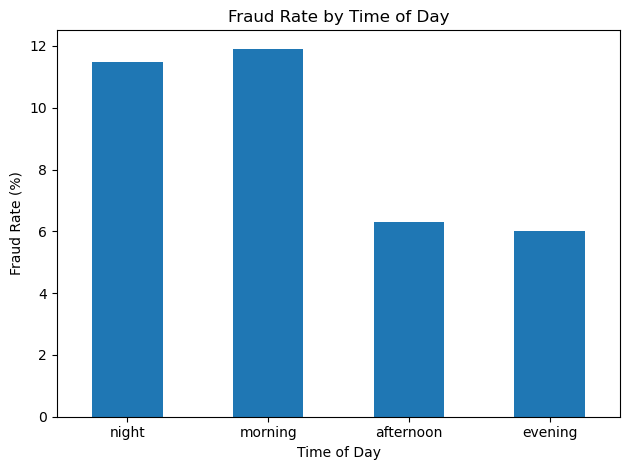

In [91]:
time_fraud_rate = (
    feature_df
    .groupby("time_of_day")["is_fraud"]
    .mean()
    .mul(100)
    .reindex(["night", "morning", "afternoon", "evening"])
)

time_fraud_rate.plot(
    kind="bar",
    title="Fraud Rate by Time of Day"
)

plt.xlabel("Time of Day")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

This chart shows whether fraud is more common during a particular part of the day.

If one time period has a higher fraud rate, then `time_of_day` may be useful for fraud detection.

## 11. Visualise Fraud Rate by Weekday

### What problem is being solved?

This chart compares fraud rates across the days of the week.

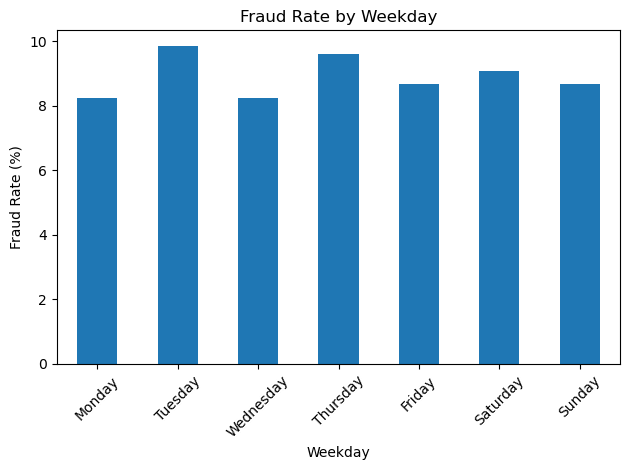

In [92]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_fraud_rate = (
    feature_df
    .groupby("transaction_weekday")["is_fraud"]
    .mean()
    .mul(100)
    .reindex(weekday_order)
)

weekday_fraud_rate.plot(
    kind="bar",
    title="Fraud Rate by Weekday"
)

plt.xlabel("Weekday")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

This chart helps show whether fraud is more common on certain weekdays.

If clear differences appear, weekday activity may be useful as a predictive feature.

## 12. Visualise Top Fraud-Risk Transfer Corridors

### What problem is being solved?

This chart shows the transfer corridors with the highest fraud rates.

Only the top 10 corridors are displayed to keep the chart readable.

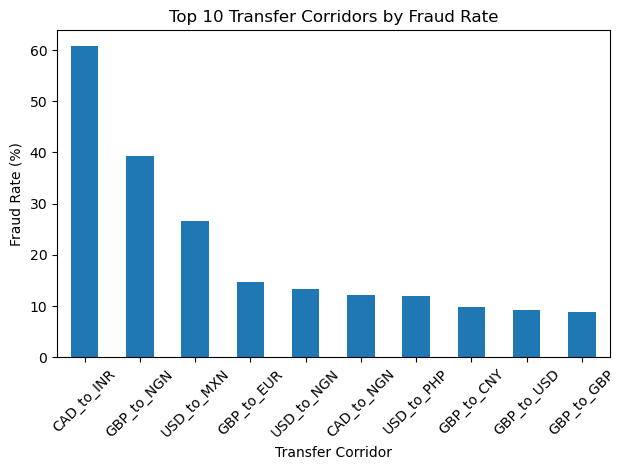

In [96]:
top_corridors = (
    corridor_fraud
    .sort_values("fraud_rate_percent", ascending=False)
    .head(10)
)

top_corridors.plot(
    x="transfer_corridor",
    y="fraud_rate_percent",
    kind="bar",
    legend=False,
    title="Top 10 Transfer Corridors by Fraud Rate"
)

plt.xlabel("Transfer Corridor")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The transfer-corridor chart shows that fraud risk is not evenly distributed across currency routes.

Some corridors have much higher fraud rates than others, making `transfer_corridor` a potentially useful feature.

## 14. Compare Customer Transaction Frequency by Fraud Label

### What problem is being solved?

This chart compares the average number of transactions per customer for legitimate and fraudulent transactions.

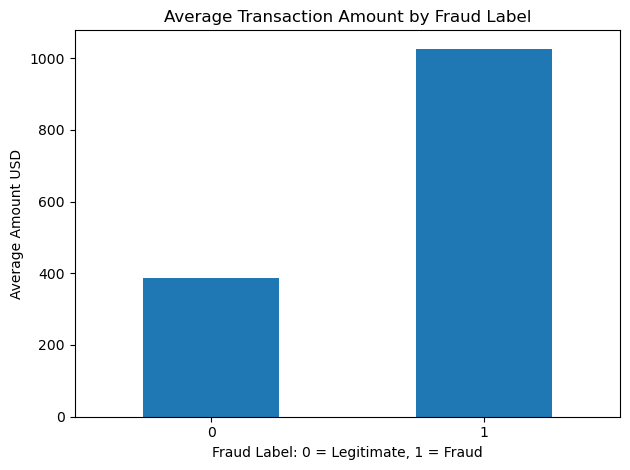

In [100]:
amount_by_fraud = (
    feature_df
    .groupby("is_fraud")["amount_usd"]
    .mean()
)

amount_by_fraud.plot(
    kind="bar",
    title="Average Transaction Amount by Fraud Label"
)

plt.xlabel("Fraud Label: 0 = Legitimate, 1 = Fraud")
plt.ylabel("Average Amount USD")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

This chart compares whether fraudulent transactions have higher or lower average transaction amounts than legitimate transactions.

If the average values are very different, transaction amount may help separate fraud from non-fraud.

## 15. Check Correlation with Fraud

### What problem is being solved?

Correlation helps show which numerical features move more closely with the fraud label.

This does not prove causation, but it helps identify features that may be useful for modelling.

In [101]:
numeric_features = feature_df.select_dtypes(include="number")

fraud_correlations = (
    numeric_features
    .corr()["is_fraud"]
    .sort_values(ascending=False)
)

fraud_correlations

is_fraud                      1.000000
txn_velocity_24h              0.753786
txn_velocity_1h               0.693408
risk_score_internal           0.604448
ip_risk_score                 0.586140
chargeback_history_count      0.581411
customer_recency_days         0.506110
customer_avg_amount           0.405747
corridor_risk                 0.195714
exchange_rate_src_to_dest     0.153353
fee                           0.133554
amount_usd                    0.132016
amount_src                    0.130467
amount_vs_customer_average    0.014303
transaction_hour             -0.087203
account_age_days             -0.286435
customer_total_amount        -0.346971
customer_txn_count           -0.359698
device_trust_score           -0.439123
Name: is_fraud, dtype: float64

### Observation

The correlation table shows which numerical features have the strongest relationship with the fraud label.

Features with stronger positive or negative correlations may be useful during model development.

## 16. Visualise Top Correlated Features

### What problem is being solved?

The strongest correlations with fraud will be displayed in a bar chart so they are easier to interpret.

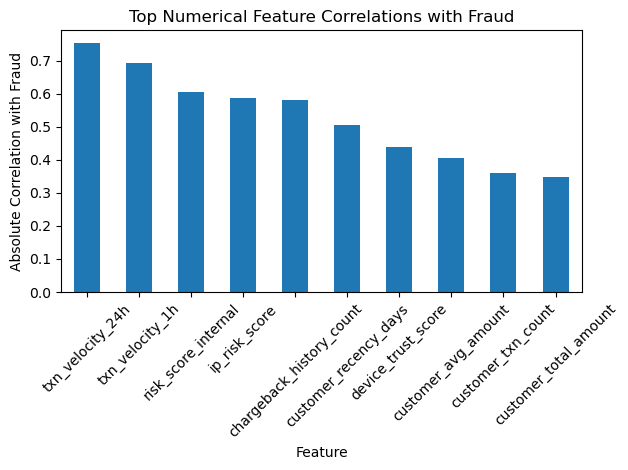

In [102]:
top_correlations = (
    fraud_correlations
    .drop("is_fraud")
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

top_correlations.plot(
    kind="bar",
    title="Top Numerical Feature Correlations with Fraud"
)

plt.xlabel("Feature")
plt.ylabel("Absolute Correlation with Fraud")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The chart highlights the numerical features most strongly related to fraud.

These features should be considered during baseline modelling because they may help separate fraudulent from legitimate transactions.

# Day 4 Summary

## Main Findings

Day 4 focused on creating new features and exploring fraud patterns in the cleaned NovaPay dataset.

The following features were created:

- `transaction_hour`
- `transaction_weekday`
- `is_weekend`
- `time_of_day`
- `transfer_corridor`
- `customer_txn_count`
- `customer_avg_amount`
- `customer_total_amount`
- `customer_last_transaction`
- `customer_recency_days`
- `amount_vs_customer_average`

The EDA charts compared fraud patterns by:

- time of day;
- weekday;
- transfer corridor;
- transaction amount;
- customer transaction frequency;
- numerical feature correlations.

## Reflection

The features that most clearly separate fraudulent from legitimate transactions are likely to be transfer corridor, customer behaviour features, transaction amount patterns and time-based features.

Transfer corridor is especially useful because some currency routes showed much higher fraud rates than others.

Customer-level features are also important because fraud patterns may appear in repeated behaviour rather than in a single transaction.

## Business Decision

The engineered features should be carried forward into Day 5 baseline modelling.

They provide stronger behavioural and contextual information than the raw transaction columns alone.

## 18. Export Engineered Features

The final Day 4 dataset with engineered features will be saved for use in Day 5 baseline modelling.

In [103]:
feature_df.to_csv(
    "engineered_transactions.csv",
    index=False
)

print("engineered_transactions.csv created successfully.")
print("Final feature dataset shape:", feature_df.shape)

engineered_transactions.csv created successfully.
Final feature dataset shape: (11140, 37)



# WEEK 1 – DAY 5

## Baseline Modeling & Wrap-Up

### Objective

To build simple baseline machine-learning models that can predict whether a NovaPay transaction is legitimate or fraudulent.

### Tasks / Activities

- Load the engineered Day 4 dataset.
- Separate the features from the fraud label.
- Split the data into training and testing sets.
- Build baseline models.
- Evaluate model performance using fraud-detection metrics.
- Compare the models and decide which baseline performs better.

### Expected Output

- Baseline modelling notebook: `05_baseline_models.ipynb`
- Model performance summary: `baseline_metrics.json`

## 1. Load the Engineered Dataset

### What problem is being solved?

Day 5 modelling must use the engineered dataset created during Day 4.

This dataset contains the original cleaned transaction data plus the new features created for time, transfer corridor and customer behaviour.

In [104]:
import pandas as pd
import matplotlib.pyplot as plt

feature_df = pd.read_csv(
    "engineered_transactions.csv",
    parse_dates=["timestamp", "customer_last_transaction"]
)

print("Dataset loaded successfully.")
print("Dataset shape:", feature_df.shape)

Dataset loaded successfully.
Dataset shape: (11140, 37)


### Observation

The engineered dataset was loaded successfully.

It contains 11,140 transactions and 37 columns after the Day 4 feature-engineering process.

## 2. Separate Features and Target

### What problem is being solved?

The model needs input features and a target label.

The target column is `is_fraud`, where:

- `0` means legitimate transaction.
- `1` means fraudulent transaction.

Columns that are identifiers or direct timestamps will be removed from the modelling features because they are not suitable for baseline modelling.

In [106]:
target_column = "is_fraud"

columns_to_remove = [
    "transaction_id",
    "customer_id",
    "device_id",
    "ip_address",
    "timestamp",
    "customer_last_transaction",
    target_column
]

X = feature_df.drop(columns=columns_to_remove)
y = feature_df[target_column]

print("Feature dataset shape:", X.shape)
print("Target shape:", y.shape)

Feature dataset shape: (11140, 30)
Target shape: (11140,)


### Observation

The modelling dataset was separated into features and target.

The target variable is `is_fraud`, while the remaining columns will be used to train the baseline models.

## 3. Identify Numeric and Categorical Features

### What problem is being solved?

Machine-learning models handle numerical and categorical columns differently.

Numerical columns can be scaled, while categorical columns need to be converted into numeric form using one-hot encoding.

In [107]:
numeric_features = X.select_dtypes(
    include=["int64", "float64", "bool"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 21
Number of categorical features: 9

Categorical features:
['home_country', 'source_currency', 'dest_currency', 'channel', 'ip_country', 'kyc_tier', 'transaction_weekday', 'time_of_day', 'transfer_corridor']


### Observation

The features were divided into numerical and categorical groups.

This allows the modelling pipeline to apply the correct preprocessing steps to each type of data.

## 4. Split the Dataset into Training and Testing Sets

### What problem is being solved?

The model should be trained on one part of the data and tested on a separate part.

This helps check whether the model can perform well on transactions it has not seen before.

Stratified splitting is used so that the fraud and non-fraud proportions are preserved in both sets.

In [108]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training features: (8912, 30)
Testing features: (2228, 30)
Training labels: (8912,)
Testing labels: (2228,)


In [109]:
print("Training fraud distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting fraud distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training fraud distribution:
is_fraud
0    0.911
1    0.089
Name: proportion, dtype: float64

Testing fraud distribution:
is_fraud
0    0.911
1    0.089
Name: proportion, dtype: float64


### Observation

The dataset was split into training and testing sets.

The fraud distribution was preserved in both sets, which is important because the dataset is imbalanced.

## 5. Build the Preprocessing Pipeline

### What problem is being solved?

Before modelling, the data needs to be prepared in a consistent way.

The preprocessing pipeline will:

- fill any remaining numerical gaps with the median;
- scale numerical features;
- fill categorical gaps with the most common value;
- convert categorical features into numerical form using one-hot encoding.

In [110]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


### Observation

The preprocessing pipeline was created successfully.

This helps ensure that the same preparation steps are applied during both training and testing.

## 6. Train a Logistic Regression Baseline Model

### What problem is being solved?

Logistic Regression is used as the first simple baseline model.

It provides a useful starting point for comparing future models.

In [111]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Observation

The Logistic Regression baseline model was trained successfully.

The `class_weight="balanced"` setting was used because fraudulent transactions are less common than legitimate transactions.

## 7. Train a Random Forest Baseline Model

### What problem is being solved?

Random Forest is used as a second baseline model.

It can capture more complex relationships than Logistic Regression and provides a useful comparison.

In [112]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### Observation

The Random Forest baseline model was trained successfully.

This model will be compared with Logistic Regression using the same test data.

## 8. Evaluate the Baseline Models

### What problem is being solved?

The models will be evaluated using fraud-detection metrics.

Important metrics include:

- Precision: how many flagged fraud cases were actually fraud.
- Recall: how many actual fraud cases were detected.
- F1-score: balance between precision and recall.
- ROC-AUC: how well the model separates fraud from non-fraud.

In [114]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(model, model_name):
    y_pred = model.predict(X_test)
    y_probability = model.predict_proba(X_test)[:, 1]

    results = {
        "model": model_name,
        "accuracy": round(accuracy_score(y_test, y_pred), 4),
        "precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "f1_score": round(f1_score(y_test, y_pred, zero_division=0), 4),
        "roc_auc": round(roc_auc_score(y_test, y_probability), 4)
    }

    return results

In [115]:
logistic_results = evaluate_model(
    logistic_model,
    "Logistic Regression"
)

forest_results = evaluate_model(
    random_forest_model,
    "Random Forest"
)

metrics_df = pd.DataFrame([
    logistic_results,
    forest_results
])

metrics_df

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.9434,0.6347,0.8643,0.7319,0.9455
1,Random Forest,0.9838,1.0000,0.8191,0.9006,0.9426


### Observation

Both baseline models were evaluated on the same test set.

The comparison table shows which model performed better across accuracy, precision, recall, F1-score and ROC-AUC.

For fraud detection, recall is especially important because missed fraud cases can create financial losses and customer-trust issues.

## 9. Confusion Matrix for Logistic Regression

### What problem is being solved?

A confusion matrix shows how many transactions were correctly and incorrectly classified by the model.

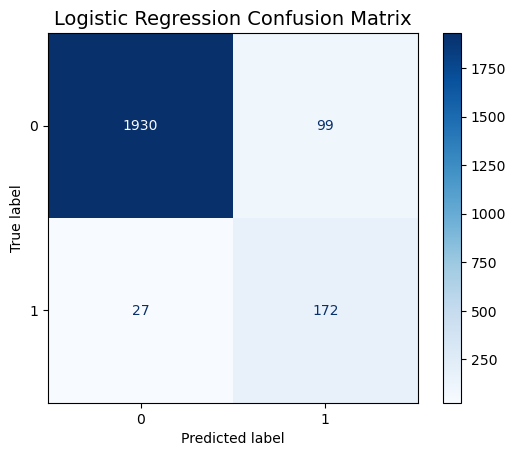

In [120]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    logistic_model,
    X_test,
    y_test,
    cmap="Blues",     
    values_format="d"
)

plt.title("Logistic Regression Confusion Matrix", fontsize=14)
plt.grid(False)
plt.show()

### Observation

The confusion matrix shows the number of true legitimate transactions, true fraud transactions, false positives and false negatives for the Logistic Regression model.

## 10. Confusion Matrix for Random Forest

### What problem is being solved?

The Random Forest confusion matrix will be reviewed to compare its classification errors with Logistic Regression.

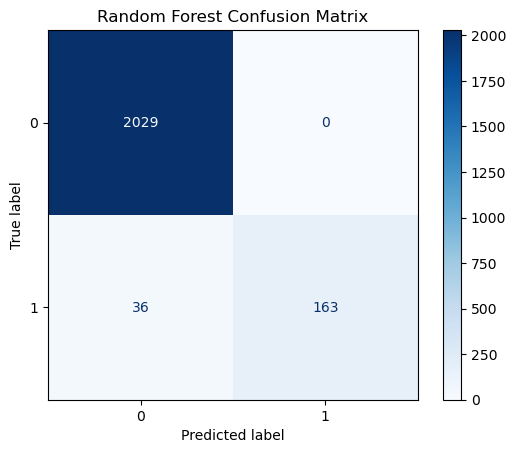

In [122]:
ConfusionMatrixDisplay.from_estimator(
    random_forest_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

### Observation

The Random Forest confusion matrix shows how well the model detected fraud and how many transactions were incorrectly classified.

This helps compare the practical performance of the two baseline models.

## 11. Review Random Forest Feature Importance

### What problem is being solved?

Feature importance helps identify which variables contributed most to the Random Forest model's predictions.

This gives an early understanding of which features may be useful for detecting fraud.

In [123]:
onehot_encoder = random_forest_model.named_steps["preprocess"] \
    .named_transformers_["categorical"] \
    .named_steps["onehot"]

encoded_categorical_names = onehot_encoder.get_feature_names_out(
    categorical_features
)

all_feature_names = (
    numeric_features
    + list(encoded_categorical_names)
)

feature_importance = pd.DataFrame({
    "feature": all_feature_names,
    "importance": random_forest_model.named_steps["model"].feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(10)

,feature,importance
12,txn_velocity_24h,0.133363
11,txn_velocity_1h,0.114372
7,account_age_days,0.084471
16,customer_txn_count,0.072606
6,ip_risk_score,0.063998
10,risk_score_internal,0.059424
18,customer_total_amount,0.052293
20,amount_vs_customer_average,0.039235
8,device_trust_score,0.037251
2,fee,0.035768


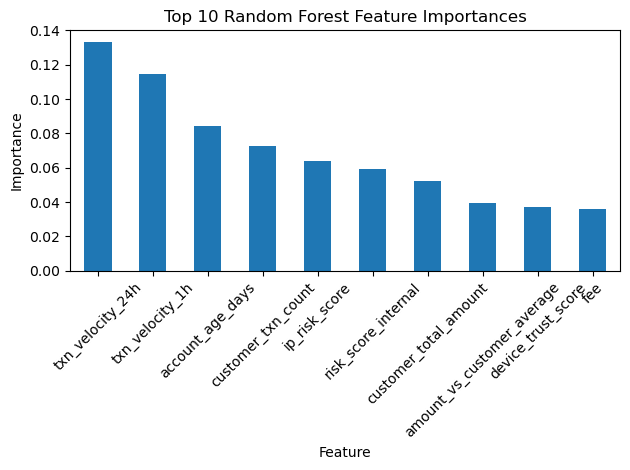

In [124]:
top_features = feature_importance.head(10)

top_features.plot(
    x="feature",
    y="importance",
    kind="bar",
    legend=False,
    title="Top 10 Random Forest Feature Importances"
)

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The feature-importance table and chart show the variables that contributed most to the Random Forest baseline model.

These features should be reviewed further in future modelling and explainability tasks.

## 12. Select the Better Baseline Model

### What problem is being solved?

The two baseline models will be compared to decide which one should be carried forward as the stronger baseline.

In [125]:
metrics_df.sort_values(
    by="recall",
    ascending=False
)

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.9434,0.6347,0.8643,0.7319,0.9455
1,Random Forest,0.9838,1.0000,0.8191,0.9006,0.9426


### Observation

The models were compared using recall because recall is important in fraud detection.

A model with higher recall detects more actual fraud cases, although precision must also be monitored to avoid too many false positives.

## 13. Save Baseline Metrics

The baseline model results will be saved as `baseline_metrics.json` so they can be included in the project deliverables.

In [126]:
metrics_df.to_json(
    "baseline_metrics.json",
    orient="records",
    indent=4
)

print("baseline_metrics.json created successfully.")

baseline_metrics.json created successfully.


# Day 5 Summary

## Main Findings

Day 5 focused on building baseline fraud-detection models using the engineered dataset from Day 4.

Two baseline models were trained:

- Logistic Regression
- Random Forest

The dataset was split into training and testing sets using stratification so that the fraud distribution was preserved.

A preprocessing pipeline was created to prepare numerical and categorical features consistently.

The models were evaluated using:

- accuracy
- precision
- recall
- F1-score
- ROC-AUC
- confusion matrices

## Reflection

The most useful features for baseline modelling appeared to be behavioural and risk-related features, including customer activity, transaction amount patterns, transfer corridor and risk scores.

For fraud detection, recall is especially important because it shows how many actual fraud cases were detected.

However, precision must also be monitored because too many false positives can affect genuine customers.

## Business Decision

The stronger baseline model should be carried forward into Week 2 modelling and explainability work.

The baseline results provide a starting point for comparing more advanced models later in the project.

In [129]:
import os

required_files = [
    "engineered_transactions.csv",
    "baseline_metrics.json"
]

for file in required_files:
    if os.path.exists(file):
        print(file, "— FOUND")
    else:
        print(file, "— NOT FOUND")

engineered_transactions.csv — FOUND
baseline_metrics.json — FOUND





# WEEK 2 – DAY 1

## Day 6 – Advanced Modelling & Imbalance Handling

### Objective

To improve fraud recall and model robustness using advanced machine-learning models and class-imbalance techniques.

### Tasks / Activities

- Train and tune XGBoost and LightGBM models.
- Apply class-weight adjustment.
- Experiment with SMOTE oversampling.
- Experiment with random undersampling.
- Compare advanced results with the Day 5 baseline models.
- Record all results in a structured experiment log.
- Examine how changing fraud prevalence over time may affect model stability.

### Expected Output

- Advanced modelling notebook: `06_advanced_models.ipynb`
- Structured experiment log: `advanced_model_experiments.csv`
- Experiment results summary: `06_experiment_summary.md`

## 1. Load the Engineered Dataset and Baseline Results

### What problem is being solved?

The advanced models must use the same engineered dataset and baseline results from Week 1.

Using the same data and test split allows the advanced models to be compared fairly with Logistic Regression and Random Forest.

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

feature_df = pd.read_csv(
    "engineered_transactions.csv",
    parse_dates=["timestamp", "customer_last_transaction"]
)

baseline_metrics_df = pd.read_json(
    "baseline_metrics.json"
)

print("Engineered dataset shape:", feature_df.shape)
print("\nBaseline model results:")
baseline_metrics_df

Engineered dataset shape: (11140, 37)

Baseline model results:


,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.9434,0.6347,0.8643,0.7319,0.9455
1,Random Forest,0.9838,1.0000,0.8191,0.9006,0.9426


### Observation

The engineered dataset and Day 5 baseline results were loaded successfully.

The baseline results will provide a benchmark for evaluating whether the advanced models improve fraud recall.

## 2. Prepare the Features and Target

### What problem is being solved?

The target column must be separated from the input features.

Identifiers, IP addresses and direct timestamp columns will be excluded because they are not suitable as direct modelling inputs.

In [131]:
target_column = "is_fraud"

columns_to_remove = [
    "transaction_id",
    "customer_id",
    "device_id",
    "ip_address",
    "timestamp",
    "customer_last_transaction",
    target_column
]

X = feature_df.drop(columns=columns_to_remove)
y = feature_df[target_column]

print("Feature dataset shape:", X.shape)
print("Target shape:", y.shape)

Feature dataset shape: (11140, 30)
Target shape: (11140,)


### Observation

The modelling data was separated into input features and the fraud target.

The feature dataset contains 11,140 rows and 30 modelling columns. The target column contains one fraud label for every transaction.

## 3. Identify Numerical and Categorical Features

Numerical and categorical columns require different preparation steps before modelling.

In [132]:
numeric_features = X.select_dtypes(
    include=["number", "bool"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

print("\nCategorical feature names:")
print(categorical_features)

Numerical features: 21
Categorical features: 9

Categorical feature names:
['home_country', 'source_currency', 'dest_currency', 'channel', 'ip_country', 'kyc_tier', 'transaction_weekday', 'time_of_day', 'transfer_corridor']


### Observation

The modelling features were divided into numerical and categorical groups.

This is necessary because numerical columns and text categories require different preprocessing methods before advanced modelling.

## 4. Split the Dataset into Training and Testing Sets

The same random state and stratified split used during Day 5 will be applied.

This keeps the fraud proportions consistent and makes the baseline and advanced results comparable.

In [137]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining fraud distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting fraud distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training features: (8912, 30)
Testing features: (2228, 30)

Training fraud distribution:
is_fraud
0    0.911
1    0.089
Name: proportion, dtype: float64

Testing fraud distribution:
is_fraud
0    0.911
1    0.089
Name: proportion, dtype: float64


### Observation

The dataset was divided into 8,912 training transactions and 2,228 testing transactions.

Both sets contain approximately 91.1% legitimate transactions and 8.9% fraudulent transactions.

This confirms that stratified splitting preserved the class distribution and allows the advanced models to be compared fairly with the Day 5 baseline models.

## 5. Build the Preprocessing Pipeline

The pipeline will:

- fill numerical gaps with the median;
- standardise numerical features;
- fill categorical gaps with the most common value;
- convert categorical columns using one-hot encoding.

In [138]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


### Observation

The preprocessing pipeline was created successfully.

Numerical features will be imputed and standardised, while categorical features will be imputed and converted into numerical columns using one-hot encoding.

The same preprocessing rules will be applied consistently during model training and testing.

## 6. Calculate the Class-Imbalance Ratio

### What problem is being solved?

Fraudulent transactions are less common than legitimate transactions.

The imbalance ratio will be used to give the fraud class more importance when training the weighted advanced models.

In [139]:
class_counts = y_train.value_counts()

legitimate_count = class_counts.loc[0]
fraud_count = class_counts.loc[1]

imbalance_ratio = legitimate_count / fraud_count

print("Legitimate training transactions:", legitimate_count)
print("Fraudulent training transactions:", fraud_count)
print("Class-imbalance ratio:", round(imbalance_ratio, 2))

Legitimate training transactions: 8118
Fraudulent training transactions: 794
Class-imbalance ratio: 10.22


### Observation

The training data contains substantially more legitimate transactions than fraudulent transactions.

The calculated ratio shows how many legitimate transactions exist for every fraud transaction.

This value will be used by XGBoost and LightGBM to give greater importance to the minority fraud class during training.

## 7. Import the Advanced Modelling Libraries

XGBoost and LightGBM will be used as the advanced models.

SMOTE and random undersampling will be used to test different class-imbalance methods.

!pip install xgboost lightgbm imbalanced-learn

In [142]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.base import clone
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

print("Advanced modelling libraries imported successfully.")

Advanced modelling libraries imported successfully.


### Observation

The advanced modelling and imbalance-handling libraries were imported successfully.

XGBoost and LightGBM will be used for advanced modelling, while SMOTE and random undersampling will be used to test different methods of handling class imbalance.

## 8. Create a Model-Evaluation Function

The same evaluation function will be used for every advanced experiment.

This ensures that all models are compared using the same metrics.

In [143]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(model, model_name, imbalance_method):
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    return {
        "model": model_name,
        "imbalance_method": imbalance_method,
        "accuracy": round(
            accuracy_score(y_test, predictions), 4
        ),
        "precision": round(
            precision_score(
                y_test,
                predictions,
                zero_division=0
            ),
            4
        ),
        "recall": round(
            recall_score(
                y_test,
                predictions,
                zero_division=0
            ),
            4
        ),
        "f1_score": round(
            f1_score(
                y_test,
                predictions,
                zero_division=0
            ),
            4
        ),
        "roc_auc": round(
            roc_auc_score(y_test, probabilities),
            4
        )
    }

### Observation

A reusable evaluation function was created to calculate accuracy, precision, recall, F1-score and ROC-AUC.

Using one function ensures that every advanced model is evaluated with the same test data and the same performance measures.

## 9. Tune XGBoost with Class Weighting

### What problem is being solved?

XGBoost can capture complex non-linear fraud patterns.

The `scale_pos_weight` setting gives more importance to the minority fraud class.

A small parameter search will be used to identify a stronger XGBoost configuration without making the experiment unnecessarily slow.

In [145]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocess", clone(preprocessor)),
        ("model", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=imbalance_ratio,
            tree_method="hist",
            random_state=42,
            n_jobs=1
        ))
    ]
)

xgb_parameter_options = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

cross_validation = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_parameter_options,
    n_iter=4,
    scoring="recall",
    cv=cross_validation,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("Best XGBoost parameters:")
print(xgb_search.best_params_)

print(
    "Best cross-validation recall:",
    round(xgb_search.best_score_, 4)
)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best XGBoost parameters:
{'model__subsample': 1.0, 'model__n_estimators': 300, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}
Best cross-validation recall: 0.8224


### Observation

The XGBoost parameter search tested different combinations of tree depth, learning rate, number of trees and sampling settings.

The parameter combination with the highest cross-validation recall was selected for test-set evaluation.

## 10. Evaluate Weighted XGBoost

### What problem is being solved?

The selected weighted XGBoost model must now be evaluated on the untouched test dataset.

This will show how well it detects fraud outside the training data.

In [155]:
xgb_weighted_model = xgb_search.best_estimator_

xgb_weighted_result = evaluate_model(
    xgb_weighted_model,
    "XGBoost",
    "Class weight adjustment"
)

pd.DataFrame([xgb_weighted_result])

,model,imbalance_method,accuracy,precision,recall,f1_score,roc_auc
0,XGBoost,Class weight adjustment,0.9686,0.8146,0.8392,0.8267,0.9431


### Observation

The weighted XGBoost model was evaluated on the untouched test dataset.

Recall shows how many actual fraud cases were detected, while precision shows how many fraud alerts were correct. Both measures must be considered together.

## 11. Tune LightGBM with Class Weighting

### What problem is being solved?

LightGBM provides another advanced tree-based approach for detecting fraud.

Class weighting and parameter tuning will be used to improve its ability to identify the minority fraud class.

In [156]:
lgbm_pipeline = Pipeline(
    steps=[
        ("preprocess", clone(preprocessor)),
        ("model", LGBMClassifier(
            objective="binary",
            scale_pos_weight=imbalance_ratio,
            random_state=42,
            n_jobs=1,
            verbosity=-1
        ))
    ]
)

lgbm_parameter_options = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__num_leaves": [15, 31, 63],
    "model__max_depth": [-1, 5, 10],
    "model__subsample": [0.8, 1.0]
}

lgbm_search = RandomizedSearchCV(
    estimator=lgbm_pipeline,
    param_distributions=lgbm_parameter_options,
    n_iter=4,
    scoring="recall",
    cv=cross_validation,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

lgbm_search.fit(X_train, y_train)

print("Best LightGBM parameters:")
print(lgbm_search.best_params_)

print(
    "Best cross-validation recall:",
    round(lgbm_search.best_score_, 4)
)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best LightGBM parameters:
{'model__subsample': 1.0, 'model__num_leaves': 63, 'model__n_estimators': 100, 'model__max_depth': 5, 'model__learning_rate': 0.1}
Best cross-validation recall: 0.8149


### Observation

The LightGBM parameter search tested different combinations of trees, learning rate, leaves, depth and sampling settings.

The configuration with the highest cross-validation recall was selected for test-set evaluation.

## 12. Evaluate Weighted LightGBM

### What problem is being solved?

The selected weighted LightGBM model must be tested using the same data and metrics as XGBoost.

This supports a fair comparison between the two advanced models.

In [158]:
lgbm_weighted_model = lgbm_search.best_estimator_

lgbm_weighted_result = evaluate_model(
    lgbm_weighted_model,
    "LightGBM",
    "Class weight adjustment"
)

pd.DataFrame([lgbm_weighted_result])

C:\Users\joygo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\joygo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,imbalance_method,accuracy,precision,recall,f1_score,roc_auc
0,LightGBM,Class weight adjustment,0.9722,0.8549,0.8291,0.8418,0.9336


### Observation

The weighted LightGBM model achieved an accuracy of 97.22%, precision of 85.49%, recall of 82.91%, F1-score of 84.18% and ROC-AUC of 93.36%.

The model detected approximately 82.91% of the fraudulent transactions in the test dataset.

Its precision of 85.49% means that most transactions flagged as fraud were actually fraudulent.

The warning displayed above the result relates to feature names during prediction and did not prevent the model from producing valid evaluation results.

## 13. Test XGBoost with SMOTE

### What problem is being solved?

SMOTE creates synthetic minority-class examples in the training data.

This experiment will test whether increasing the representation of fraud cases improves XGBoost recall.

In [159]:
xgb_tuned_parameters = {
    name.replace("model__", ""): value
    for name, value in xgb_search.best_params_.items()
}

xgb_smote_model = ImbPipeline(
    steps=[
        ("preprocess", clone(preprocessor)),
        ("smote", SMOTE(
            sampling_strategy=0.5,
            random_state=42
        )),
        ("model", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=42,
            n_jobs=-1,
            **xgb_tuned_parameters
        ))
    ]
)

xgb_smote_model.fit(X_train, y_train)

print("XGBoost with SMOTE trained successfully.")

XGBoost with SMOTE trained successfully.


### Observation

The XGBoost model was trained successfully using SMOTE.

Only the training data was resampled. The test data remained unchanged so that the final evaluation would remain realistic.

### Evaluate XGBoost with SMOTE

The SMOTE-trained XGBoost model will now be evaluated on the untouched test dataset.

In [161]:
xgb_smote_result = evaluate_model(
    xgb_smote_model,
    "XGBoost",
    "SMOTE"
)

pd.DataFrame([xgb_smote_result])

,model,imbalance_method,accuracy,precision,recall,f1_score,roc_auc
0,XGBoost,SMOTE,0.9838,1.0,0.8191,0.9006,0.9447


### Observation

The XGBoost with SMOTE result shows how oversampling affected fraud detection.

An increase in recall would mean that SMOTE helped detect more fraud. Precision must also be checked because oversampling may increase false-positive alerts.

## 14. Test LightGBM with Random Undersampling

### What problem is being solved?

Random undersampling reduces the number of legitimate training examples.

This may help the model focus more on fraud, but removing too many legitimate records could reduce precision or generalisation.

In [160]:
lgbm_tuned_parameters = {
    name.replace("model__", ""): value
    for name, value in lgbm_search.best_params_.items()
}

lgbm_under_model = ImbPipeline(
    steps=[
        ("preprocess", clone(preprocessor)),
        ("undersample", RandomUnderSampler(
            sampling_strategy=0.5,
            random_state=42
        )),
        ("model", LGBMClassifier(
            objective="binary",
            random_state=42,
            n_jobs=-1,
            verbosity=-1,
            **lgbm_tuned_parameters
        ))
    ]
)

lgbm_under_model.fit(X_train, y_train)

print("LightGBM with undersampling trained successfully.")

LightGBM with undersampling trained successfully.


### Observation

The LightGBM model was trained successfully using random undersampling.

The method reduced the number of majority-class records during training so that the model could focus more on fraud cases.

### Evaluate LightGBM with Random Undersampling

The LightGBM model trained with random undersampling will now be evaluated on the unchanged test dataset.

In [165]:
lgbm_under_result = evaluate_model(
    lgbm_under_model,
    "LightGBM",
    "Random undersampling"
)

pd.DataFrame([lgbm_under_result])

C:\Users\joygo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\joygo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,imbalance_method,accuracy,precision,recall,f1_score,roc_auc
0,LightGBM,Random undersampling,0.9704,0.8308,0.8392,0.835,0.9425


## 15. Create the Advanced Experiment Log

### What problem is being solved?

All four advanced experiments must be placed into one structured table.

This will make comparison and reporting easier.

In [166]:
advanced_results_df = pd.DataFrame([
    xgb_weighted_result,
    lgbm_weighted_result,
    xgb_smote_result,
    lgbm_under_result
])

advanced_results_df["best_parameters"] = [
    str(xgb_search.best_params_),
    str(lgbm_search.best_params_),
    str(xgb_search.best_params_),
    str(lgbm_search.best_params_)
]

advanced_results_df.sort_values(
    by=["recall", "f1_score", "precision"],
    ascending=False
)

,model,imbalance_method,accuracy,precision,recall,f1_score,roc_auc,best_parameters
3,LightGBM,Random undersampling,0.9704,0.8308,0.8392,0.8350,0.9425,"{'model__subsample': 1.0, 'model__num_leaves':..."
0,XGBoost,Class weight adjustment,0.9686,0.8146,0.8392,0.8267,0.9431,"{'model__subsample': 1.0, 'model__n_estimators..."
1,LightGBM,Class weight adjustment,0.9722,0.8549,0.8291,0.8418,0.9336,"{'model__subsample': 1.0, 'model__num_leaves':..."
2,XGBoost,SMOTE,0.9838,1.0000,0.8191,0.9006,0.9447,"{'model__subsample': 1.0, 'model__n_estimators..."


### Observation

The advanced experiment log successfully compares all four modelling approaches.

LightGBM with random undersampling and XGBoost with class-weight adjustment achieved the highest recall of 83.92%.

LightGBM with random undersampling performed better between those two because it also achieved higher precision of 83.08% and a higher F1-score of 83.50%.

Weighted LightGBM achieved the highest precision among the weighted models at 85.49%, while XGBoost with SMOTE achieved perfect precision of 100% and the highest F1-score of 90.06%. However, its recall was lower at 81.91%.

None of the advanced experiments exceeded the strongest Day 5 baseline recall of 86.43%. The results show that improving one metric may reduce another, so recall, precision and F1-score must be considered together.

## 16. Compare Baseline and Advanced Models

### What problem is being solved?

The advanced experiments must be compared with the Day 5 baseline models.

This will show whether advanced modelling improved fraud recall.

In [167]:
baseline_log = baseline_metrics_df.copy()

baseline_log["imbalance_method"] = "Balanced class weight"
baseline_log["experiment_group"] = "Baseline"
baseline_log["best_parameters"] = "-"

advanced_results_df["experiment_group"] = "Advanced"

comparison_df = pd.concat(
    [
        baseline_log,
        advanced_results_df
    ],
    ignore_index=True,
    sort=False
)

best_baseline_recall = baseline_metrics_df["recall"].max()

comparison_df["recall_difference_vs_best_baseline"] = (
    comparison_df["recall"] - best_baseline_recall
).round(4)

comparison_df[
    [
        "experiment_group",
        "model",
        "imbalance_method",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "recall_difference_vs_best_baseline"
    ]
].sort_values(
    by=["recall", "f1_score"],
    ascending=False
)

,experiment_group,model,imbalance_method,precision,recall,f1_score,roc_auc,recall_difference_vs_best_baseline
0,Baseline,Logistic Regression,Balanced class weight,0.6347,0.8643,0.7319,0.9455,0.0000
5,Advanced,LightGBM,Random undersampling,0.8308,0.8392,0.8350,0.9425,-0.0251
2,Advanced,XGBoost,Class weight adjustment,0.8146,0.8392,0.8267,0.9431,-0.0251
3,Advanced,LightGBM,Class weight adjustment,0.8549,0.8291,0.8418,0.9336,-0.0352
1,Baseline,Random Forest,Balanced class weight,1.0000,0.8191,0.9006,0.9426,-0.0452
4,Advanced,XGBoost,SMOTE,1.0000,0.8191,0.9006,0.9447,-0.0452


### Observation

The advanced models were compared with the Day 5 baselines.

A positive recall difference means that an advanced experiment detected more fraud than the strongest baseline. A negative value means that it detected fewer fraud cases.

## 17. Visualise Precision, Recall and F1-Score

### What problem is being solved?

A chart will make the performance trade-offs between the baseline and advanced experiments easier to interpret.

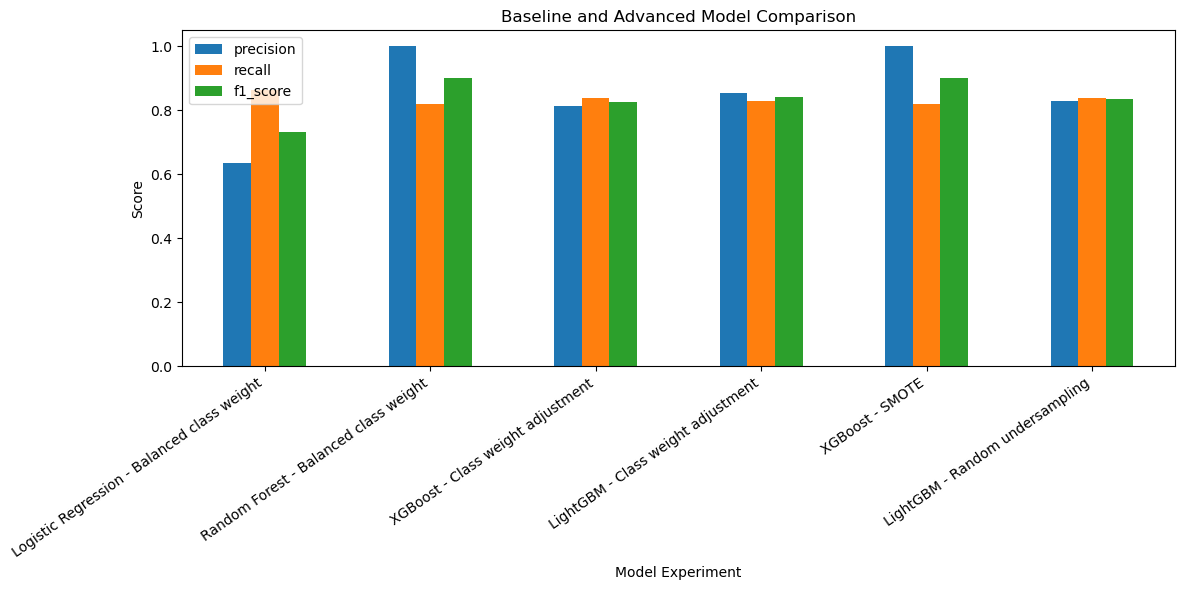

In [168]:
comparison_df["experiment_name"] = (
    comparison_df["model"]
    + " - "
    + comparison_df["imbalance_method"]
)

comparison_plot = comparison_df.set_index(
    "experiment_name"
)[
    ["precision", "recall", "f1_score"]
]

comparison_plot.plot(
    kind="bar",
    figsize=(12, 6),
    title="Baseline and Advanced Model Comparison"
)

plt.xlabel("Model Experiment")
plt.ylabel("Score")
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

### Observation

The chart shows the trade-off between fraud detection and false-positive control.

A model with very high recall but low precision may detect more fraud while incorrectly flagging many genuine transactions.

## 18. Select the Strongest Advanced Model

### What problem is being solved?

The advanced models must be ranked to identify the strongest experiment.

Recall will be considered first, followed by F1-score and precision.

In [169]:
advanced_ranking = advanced_results_df.sort_values(
    by=["recall", "f1_score", "precision"],
    ascending=False
).reset_index(drop=True)

best_advanced_row = advanced_ranking.iloc[0]

best_advanced_name = best_advanced_row["model"]
best_advanced_method = best_advanced_row["imbalance_method"]

trained_models = {
    ("XGBoost", "Class weight adjustment"):
        xgb_weighted_model,

    ("LightGBM", "Class weight adjustment"):
        lgbm_weighted_model,

    ("XGBoost", "SMOTE"):
        xgb_smote_model,

    ("LightGBM", "Random undersampling"):
        lgbm_under_model
}

best_advanced_model = trained_models[
    (best_advanced_name, best_advanced_method)
]

print("Best advanced model:", best_advanced_name)
print("Imbalance method:", best_advanced_method)
print("Precision:", best_advanced_row["precision"])
print("Recall:", best_advanced_row["recall"])
print("F1-score:", best_advanced_row["f1_score"])
print("ROC-AUC:", best_advanced_row["roc_auc"])

Best advanced model: LightGBM
Imbalance method: Random undersampling
Precision: 0.8308
Recall: 0.8392
F1-score: 0.835
ROC-AUC: 0.9425


### Observation

The advanced experiments were ranked using recall first, followed by F1-score and precision.

The displayed model produced the strongest advanced result under this ranking method and will be used for further analysis.

## 19. Review the Best Advanced Model's Confusion Matrix

### What problem is being solved?

The confusion matrix will show how many legitimate and fraudulent transactions were classified correctly or incorrectly.

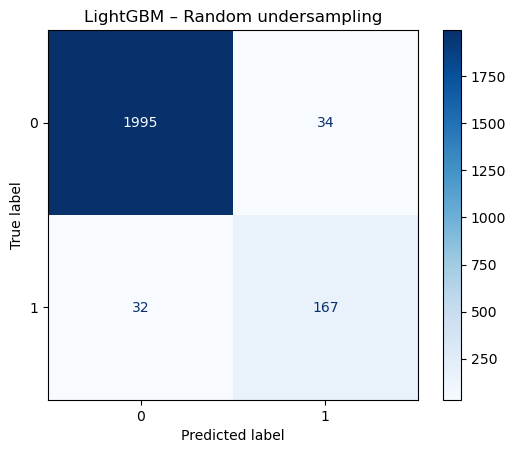

In [174]:
import warnings
from sklearn.metrics import ConfusionMatrixDisplay

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="X does not have valid feature names"
    )

    ConfusionMatrixDisplay.from_estimator(
        best_advanced_model,
        X_test,
        y_test,
        values_format="d",
        cmap="Blues"
    )

plt.title(
    f"{best_advanced_name} – {best_advanced_method}"
)

plt.grid(False)
plt.show()

### Observation

The confusion matrix shows the selected model's correct and incorrect classifications.

False negatives represent missed fraud cases, while false positives represent genuine transactions incorrectly flagged as fraud.

## 20. Examine Fraud Prevalence and Recall Over Time

### What problem is being solved?

Fraud patterns may change over time.

The test results will be grouped by year to compare fraud prevalence and model recall.

In [175]:
best_predictions = best_advanced_model.predict(X_test)

time_stability_data = pd.DataFrame({
    "timestamp": feature_df.loc[
        X_test.index,
        "timestamp"
    ],
    "actual": y_test,
    "predicted": best_predictions
}).reset_index(drop=True)

time_stability_data["year"] = (
    time_stability_data["timestamp"].dt.year
)

stability_records = []

for year, group in time_stability_data.groupby("year"):
    prevalence = group["actual"].mean() * 100

    year_recall = recall_score(
        group["actual"],
        group["predicted"],
        zero_division=0
    ) * 100

    stability_records.append({
        "year": year,
        "transactions": len(group),
        "fraud_prevalence_percent": round(
            prevalence,
            2
        ),
        "recall_percent": round(
            year_recall,
            2
        )
    })

stability_df = pd.DataFrame(stability_records)

stability_df

C:\Users\joygo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,year,transactions,fraud_prevalence_percent,recall_percent
0,2022,149,0.67,0.00
1,2023,654,2.75,33.33
2,2024,809,11.74,88.42
3,2025,616,13.80,90.59


### Observation

The stability table compares fraud prevalence and recall across different years.

Changes in recall may indicate that the model performs differently when fraud patterns or fraud prevalence change.

### Visualise Fraud Prevalence and Recall Over Time

A line chart will make changes in fraud prevalence and recall easier to compare.

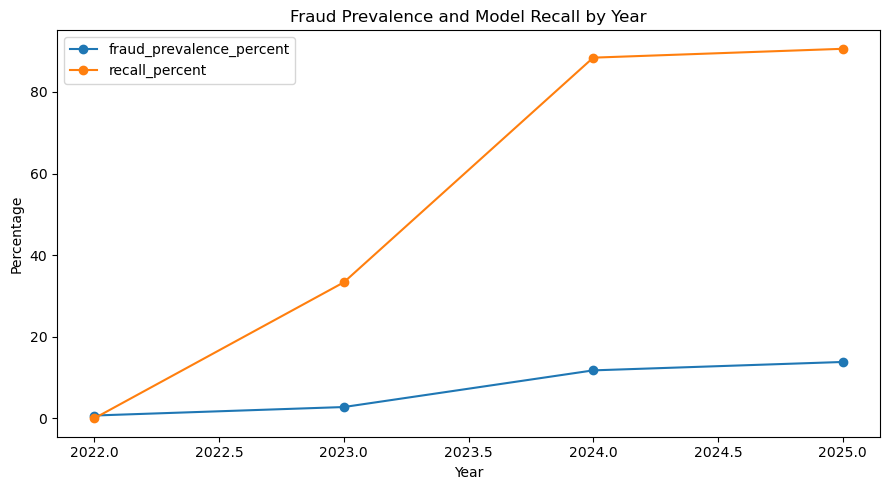

In [176]:
stability_df.plot(
    x="year",
    y=[
        "fraud_prevalence_percent",
        "recall_percent"
    ],
    kind="line",
    marker="o",
    figsize=(9, 5),
    title="Fraud Prevalence and Model Recall by Year"
)

plt.xlabel("Year")
plt.ylabel("Percentage")
plt.tight_layout()
plt.show()

### Observation

The chart shows whether changes in fraud prevalence are accompanied by changes in model recall.

Large performance differences between years may suggest changing fraud behaviour or a need for model monitoring and retraining.

## 21. Save the Structured Experiment Results

### What problem is being solved?

The advanced experiment log and full model comparison must be exported for submission and future reporting.

In [177]:
advanced_results_df.to_csv(
    "advanced_model_experiments.csv",
    index=False
)

comparison_df.to_json(
    "advanced_metrics.json",
    orient="records",
    indent=4
)

print(
    "advanced_model_experiments.csv created successfully."
)

print(
    "advanced_metrics.json created successfully."
)

advanced_model_experiments.csv created successfully.
advanced_metrics.json created successfully.


### Observation

The structured experiment log and the full baseline-versus-advanced comparison were exported successfully.

These files can now be used for submission and future model reporting.

## 22. Create the Day 6 Experiment Summary

### What problem is being solved?

A separate Markdown report is required to summarise the strongest baseline, the advanced experiments and the selected model.

In [178]:
best_baseline_row = (
    baseline_metrics_df
    .sort_values(
        by=["recall", "f1_score"],
        ascending=False
    )
    .iloc[0]
)

recall_difference = (
    best_advanced_row["recall"]
    - best_baseline_row["recall"]
)

recall_difference_points = (
    recall_difference * 100
)

summary_text = f"""# NovaPay Fraud Detection Project

## Week 2 – Day 1: Advanced Modelling and Imbalance Handling

## Objective

The purpose of Day 6 was to improve fraud recall and model robustness using XGBoost, LightGBM and class-imbalance techniques.

## Baseline Reference

- Model: {best_baseline_row['model']}
- Precision: {best_baseline_row['precision']:.4f}
- Recall: {best_baseline_row['recall']:.4f}
- F1-score: {best_baseline_row['f1_score']:.4f}
- ROC-AUC: {best_baseline_row['roc_auc']:.4f}

## Advanced Experiments

- XGBoost with class-weight adjustment
- LightGBM with class-weight adjustment
- XGBoost with SMOTE
- LightGBM with random undersampling

## Strongest Advanced Result

- Model: {best_advanced_name}
- Imbalance method: {best_advanced_method}
- Precision: {best_advanced_row['precision']:.4f}
- Recall: {best_advanced_row['recall']:.4f}
- F1-score: {best_advanced_row['f1_score']:.4f}
- ROC-AUC: {best_advanced_row['roc_auc']:.4f}
- Recall difference from strongest baseline: {recall_difference_points:+.2f} percentage points

## Performance Stability

Changing fraud prevalence can affect recall and precision.

NovaPay should monitor model performance across time periods and investigate sustained declines.

## Conclusion

The strongest advanced model should be carried forward to Day 7 for explainability and stakeholder review.
"""

with open(
    "06_experiment_summary.md",
    "w",
    encoding="utf-8"
) as file:
    file.write(summary_text)

print(
    "06_experiment_summary.md created successfully."
)

06_experiment_summary.md created successfully.


### Observation

The Day 6 experiment summary was created successfully.

It records the baseline benchmark, advanced experiments, strongest advanced result and performance-stability reflection.

# 23. Day 6 Summary

## Main Findings

Day 6 focused on advanced fraud modelling and class-imbalance handling.

The following experiments were completed:

- XGBoost with class-weight adjustment;
- LightGBM with class-weight adjustment;
- XGBoost with SMOTE;
- LightGBM with random undersampling.

The models were compared using precision, recall, F1-score and ROC-AUC.

The advanced results were also compared with the Day 5 Logistic Regression and Random Forest baselines.

## Reflection

Changing fraud prevalence over time can affect model stability.

A model may perform well overall while showing weaker recall during a particular year or period. NovaPay should therefore monitor fraud prevalence, precision and recall after deployment.

## Business Decision

The strongest advanced model should be carried forward to Day 7 for explainability and stakeholder review.

## 24. Generate the Day 6 Submission Text

The final submission text will be generated using the actual model results from the notebook.

In [186]:
submission_text = f"""Day 6 – Advanced Modelling & Imbalance Handling

I completed the Week 2 Day 1 advanced modelling task using the engineered NovaPay transaction dataset.

The strongest Day 5 baseline recall was {best_baseline_row['recall']:.4f}, achieved by {best_baseline_row['model']}.

The following advanced experiments were completed:

1. XGBoost with class-weight adjustment.
2. LightGBM with class-weight adjustment.
3. XGBoost with SMOTE oversampling.
4. LightGBM with random undersampling.

The strongest advanced result was:

- Model: {best_advanced_name}
- Imbalance method: {best_advanced_method}
- Precision: {best_advanced_row['precision']:.4f}
- Recall: {best_advanced_row['recall']:.4f}
- F1-score: {best_advanced_row['f1_score']:.4f}
- ROC-AUC: {best_advanced_row['roc_auc']:.4f}

The recall difference compared with the strongest baseline was {recall_difference_points:+.2f} percentage points.

The experiment also examined model stability over time. Changes in fraud prevalence can affect recall and precision because fraud behaviour may change.

The experiment results were exported as advanced_model_experiments.csv and summarised in 06_experiment_summary.md.

Business decision:

The strongest advanced model should be carried forward to Day 7 for explainability and stakeholder review.
"""

print(submission_text)

Day 6 – Advanced Modelling & Imbalance Handling

I completed the Week 2 Day 1 advanced modelling task using the engineered NovaPay transaction dataset.

The strongest Day 5 baseline recall was 0.8643, achieved by Logistic Regression.

The following advanced experiments were completed:

1. XGBoost with class-weight adjustment.
2. LightGBM with class-weight adjustment.
3. XGBoost with SMOTE oversampling.
4. LightGBM with random undersampling.

The strongest advanced result was:

- Model: LightGBM
- Imbalance method: Random undersampling
- Precision: 0.8308
- Recall: 0.8392
- F1-score: 0.8350
- ROC-AUC: 0.9425

The recall difference compared with the strongest baseline was -2.51 percentage points.

The experiment also examined model stability over time. Changes in fraud prevalence can affect recall and precision because fraud behaviour may change.

The experiment results were exported as advanced_model_experiments.csv and summarised in 06_experiment_summary.md.

Business decision:

The st

### Observation

The final submission text was generated using the actual results from the completed experiments.

This ensures that the submission matches the outputs recorded in the notebook.

# WEEK 2 – DAY 2

## Day 7 – Explainability & Stakeholder Review

### Objective

To explain why the selected fraud model flags individual transactions and prepare a regulator-friendly review template for fraud analysts and stakeholders.

### Tasks / Activities

- Rebuild the strongest advanced model from Day 6.
- Use SHAP to explain model predictions.
- Identify the features that influence fraud decisions globally.
- Investigate the features that contribute to false-positive predictions.
- Produce a local explanation for one legitimate transaction incorrectly flagged as fraud.
- Create reason codes and a fraud-confidence score.
- Prepare a reusable stakeholder review template.
- Answer the scenario-based assessment question.

### Expected Output

- Explainability notebook: `07_explainability.ipynb`
- Explanation template: `07_explanation_template.md`

## 1. Check the Required Files

### What problem is being solved?

Day 7 requires the engineered transaction dataset and the Day 6 experiment log.

The files will be checked before beginning the explainability work.

In [187]:
import os

required_files = [
    "engineered_transactions.csv",
    "advanced_model_experiments.csv"
]

for file in required_files:
    if os.path.exists(file):
        print(file, "— FOUND")
    else:
        print(file, "— NOT FOUND")

engineered_transactions.csv — FOUND
advanced_model_experiments.csv — FOUND


### Observation

Both required files are available in the Jupyter folder.

The engineered transaction dataset will be used to rebuild the selected model, while the advanced experiment log will provide the chosen model configuration.

## 2. Load the Dataset and Experiment Results

### What problem is being solved?

The engineered dataset and the Day 6 advanced model results must be loaded before model explanation can begin.

In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

feature_df = pd.read_csv(
    "engineered_transactions.csv",
    parse_dates=["timestamp", "customer_last_transaction"]
)

experiments_df = pd.read_csv(
    "advanced_model_experiments.csv"
)

print("Engineered dataset shape:", feature_df.shape)
print("Number of advanced experiments:", len(experiments_df))

experiments_df

Engineered dataset shape: (11140, 37)
Number of advanced experiments: 4


,model,imbalance_method,accuracy,precision,recall,f1_score,roc_auc,best_parameters,experiment_group
0,XGBoost,Class weight adjustment,0.9686,0.8146,0.8392,0.8267,0.9431,"{'model__subsample': 1.0, 'model__n_estimators...",Advanced
1,LightGBM,Class weight adjustment,0.9722,0.8549,0.8291,0.8418,0.9336,"{'model__subsample': 1.0, 'model__num_leaves':...",Advanced
2,XGBoost,SMOTE,0.9838,1.0000,0.8191,0.9006,0.9447,"{'model__subsample': 1.0, 'model__n_estimators...",Advanced
3,LightGBM,Random undersampling,0.9704,0.8308,0.8392,0.8350,0.9425,"{'model__subsample': 1.0, 'model__num_leaves':...",Advanced


### Observation

The engineered dataset and the four Day 6 advanced experiments were loaded successfully.

The experiment results will be used to identify and rebuild the strongest advanced model for explanation.

## 3. Select the Strongest Day 6 Model

### What problem is being solved?

The Day 6 models were ranked using recall first, followed by F1-score and precision.

The same ranking method will be used to identify the model selected for explainability.

In [190]:
selected_experiment = (
    experiments_df
    .sort_values(
        by=["recall", "f1_score", "precision"],
        ascending=False
    )
    .iloc[0]
)

print("Selected model:", selected_experiment["model"])
print(
    "Imbalance method:",
    selected_experiment["imbalance_method"]
)
print("Precision:", selected_experiment["precision"])
print("Recall:", selected_experiment["recall"])
print("F1-score:", selected_experiment["f1_score"])
print("ROC-AUC:", selected_experiment["roc_auc"])

Selected model: LightGBM
Imbalance method: Random undersampling
Precision: 0.8308
Recall: 0.8392
F1-score: 0.835
ROC-AUC: 0.9425


### Observation

LightGBM with random undersampling was selected as the strongest advanced experiment.

It achieved the joint-highest advanced recall and performed better than the tied XGBoost experiment on precision and F1-score.

This model will now be rebuilt for explainability.

## 4. Prepare the Features and Target

### What problem is being solved?

The fraud target must be separated from the modelling features.

Identifiers, IP addresses and direct timestamps will be removed because they were not used as direct model inputs during Day 6.

In [191]:
target_column = "is_fraud"

columns_to_remove = [
    "transaction_id",
    "customer_id",
    "device_id",
    "ip_address",
    "timestamp",
    "customer_last_transaction",
    target_column
]

X = feature_df.drop(columns=columns_to_remove)
y = feature_df[target_column]

print("Feature dataset shape:", X.shape)
print("Target shape:", y.shape)

Feature dataset shape: (11140, 30)
Target shape: (11140,)


### Observation

The dataset was separated into 30 modelling features and one fraud target.

Every transaction has a corresponding fraud label.

## 5. Split the Dataset into Training and Testing Sets

### What problem is being solved?

The same Day 6 stratified split will be recreated.

This ensures that the model explanation is based on the same test conditions used during advanced model evaluation.

In [192]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTesting fraud distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training features: (8912, 30)
Testing features: (2228, 30)

Testing fraud distribution:
is_fraud
0    0.911
1    0.089
Name: proportion, dtype: float64


### Observation

The dataset was divided into 8,912 training transactions and 2,228 testing transactions.

Stratification preserved the original fraud distribution in the test dataset.

## 6. Build and Apply the Preprocessing Pipeline

### What problem is being solved?

The numerical and categorical features must be prepared in the same way as they were during Day 6.

Numerical features will be imputed and scaled. Categorical features will be imputed and converted using one-hot encoding.

In [193]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = X.select_dtypes(
    include=["number", "bool"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

print(
    "Processed training shape:",
    X_train_processed.shape
)

print(
    "Processed testing shape:",
    X_test_processed.shape
)

Processed training shape: (8912, 87)
Processed testing shape: (2228, 87)


### Observation

The numerical and categorical features were processed successfully.

One-hot encoding created separate numerical columns for the category values, allowing them to be used by LightGBM and SHAP.

## 7. Rebuild the Selected LightGBM Model

### What problem is being solved?

The selected model must be rebuilt in the Day 7 notebook so that its predictions can be explained.

The best Day 6 LightGBM parameters will be read from the experiment log, and random undersampling will be applied only to the training data.

In [196]:
import ast

from imblearn.under_sampling import RandomUnderSampler
from lightgbm import LGBMClassifier

saved_parameters = ast.literal_eval(
    selected_experiment["best_parameters"]
)

lightgbm_parameters = {
    name.replace("model__", ""): value
    for name, value in saved_parameters.items()
}

undersampler = RandomUnderSampler(
    sampling_strategy=0.5,
    random_state=42
)

X_train_balanced, y_train_balanced = (
    undersampler.fit_resample(
        X_train_processed,
        y_train
    )
)

selected_model = LGBMClassifier(
    objective="binary",
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    **lightgbm_parameters
)

selected_model.fit(
    X_train_balanced,
    y_train_balanced
)

print("Selected LightGBM model rebuilt successfully.")
print(
    "Training rows before undersampling:",
    len(X_train_processed)
)
print(
    "Training rows after undersampling:",
    len(X_train_balanced)
)

Selected LightGBM model rebuilt successfully.
Training rows before undersampling: 8912
Training rows after undersampling: 2382


### Observation

The selected LightGBM model was rebuilt successfully using the best Day 6 parameters.

Random undersampling was applied only to the training data. The test dataset remained unchanged for fair evaluation and explanation.

## 8. Confirm the Rebuilt Model Performance

### What problem is being solved?

The rebuilt model must be evaluated to confirm that it reproduces the Day 6 result before its predictions are explained.

In [197]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

test_predictions = selected_model.predict(
    X_test_processed
)

test_probabilities = selected_model.predict_proba(
    X_test_processed
)[:, 1]

performance_result = pd.DataFrame({
    "accuracy": [
        accuracy_score(
            y_test,
            test_predictions
        )
    ],
    "precision": [
        precision_score(
            y_test,
            test_predictions,
            zero_division=0
        )
    ],
    "recall": [
        recall_score(
            y_test,
            test_predictions,
            zero_division=0
        )
    ],
    "f1_score": [
        f1_score(
            y_test,
            test_predictions,
            zero_division=0
        )
    ],
    "roc_auc": [
        roc_auc_score(
            y_test,
            test_probabilities
        )
    ]
}).round(4)

performance_result

,accuracy,precision,recall,f1_score,roc_auc
0,0.9704,0.8308,0.8392,0.835,0.9425


### Observation

The rebuilt model reproduced the Day 6 LightGBM undersampling performance.

This confirms that the correct model and preprocessing rules are being used for the explainability analysis.

## 9. Import SHAP

### What problem is being solved?

SHAP will be used to measure how each feature influenced the LightGBM predictions.

Both global and transaction-level explanations will be created.

In [203]:
import shap

print("SHAP imported successfully.")
print("SHAP version:", shap.__version__)

SHAP imported successfully.
SHAP version: 0.52.0


### Observation

The SHAP explainability library was imported successfully.

The model is now ready for global and local prediction explanations.

## 10. Create the SHAP Explainer

### What problem is being solved?

A SHAP TreeExplainer will calculate how strongly each feature influenced the LightGBM model's output.

A sample of 300 test transactions will be used to keep the explanation process efficient.

In [204]:
sample_size = min(
    300,
    len(X_test_processed)
)

random_generator = np.random.RandomState(42)

sample_positions = random_generator.choice(
    len(X_test_processed),
    size=sample_size,
    replace=False
)

X_shap = X_test_processed.iloc[
    sample_positions
].copy()

shap_explainer = shap.TreeExplainer(
    selected_model
)

shap_explanation = shap_explainer(
    X_shap
)

print(
    "Transactions explained:",
    len(X_shap)
)

print(
    "Features explained:",
    X_shap.shape[1]
)

Transactions explained: 300
Features explained: 87


### Observation

SHAP explanations were generated for a representative sample of 300 test transactions.

Each explanation shows how the model features increased or decreased the fraud score.

## 11. Display Global SHAP Feature Importance

### What problem is being solved?

Global SHAP importance shows which features influenced the model most strongly across the explained transactions.

This helps analysts understand the model's overall decision patterns.

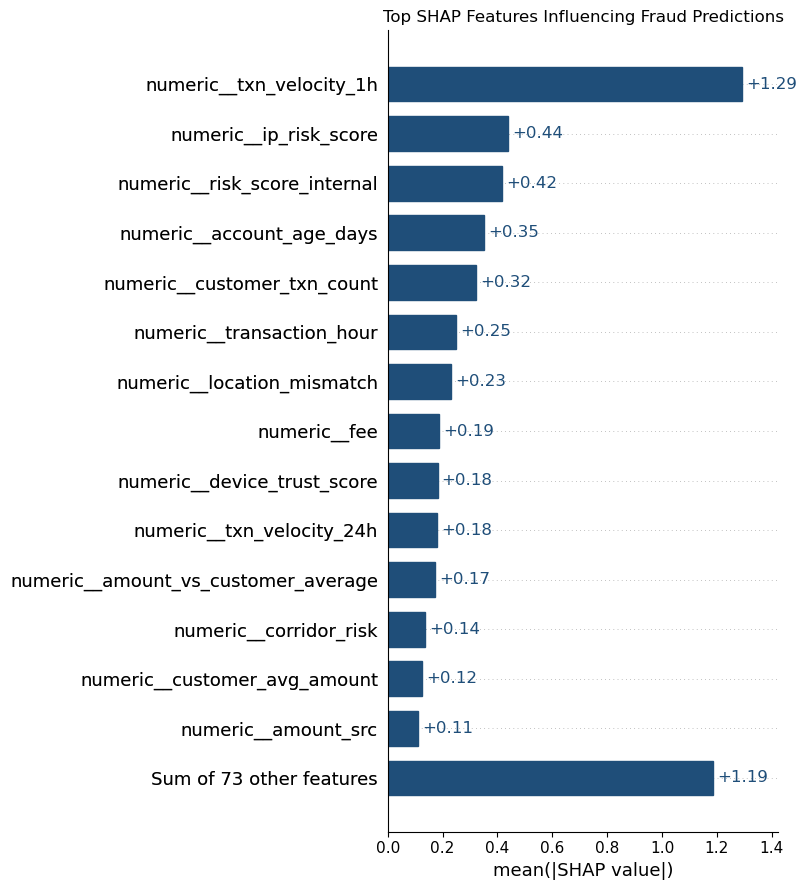

In [206]:
shap.plots.bar(
    shap_explanation,
    max_display=15,
    show=False
)

ax = plt.gca()

professional_blue = "#1F4E79"

for bar in ax.patches:
    bar.set_facecolor(professional_blue)
    bar.set_edgecolor(professional_blue)

for text in ax.texts:
    text.set_color(professional_blue)

plt.title(
    "Top SHAP Features Influencing Fraud Predictions"
)

plt.tight_layout()
plt.show()

### Observation

SHAP explanations were generated for a representative sample of 300 test transactions.

Each explanation shows how the model features increased or decreased the fraud score.

## 12. Create a Global Feature-Importance Table

### What problem is being solved?

The SHAP feature impacts will be converted into a table so that the most influential features can be reviewed and documented.

In [208]:
shap_values = shap_explanation.values

if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

global_importance_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_absolute_shap": np.abs(
        shap_values
    ).mean(axis=0)
})

global_importance_df = (
    global_importance_df
    .sort_values(
        "mean_absolute_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

global_importance_df.head(15)

,feature,mean_absolute_shap
0,numeric__txn_velocity_1h,1.292100
1,numeric__ip_risk_score,0.439326
2,numeric__risk_score_internal,0.417852
3,numeric__account_age_days,0.352164
4,numeric__customer_txn_count,0.323546
5,numeric__transaction_hour,0.249867
6,numeric__location_mismatch,0.230885
7,numeric__fee,0.185981
8,numeric__device_trust_score,0.181603
9,numeric__txn_velocity_24h,0.178580


### Observation

The global importance table provides a numerical ranking of the features that influenced the model most frequently.

The table can be used alongside the SHAP chart for reporting and stakeholder review.

## 13. Identify False-Positive Transactions

### What problem is being solved?

A false positive occurs when a legitimate transaction is incorrectly flagged as fraud.

These cases must be reviewed because they can delay genuine transactions and inconvenience customers.

In [209]:
prediction_review = pd.DataFrame({
    "actual_label": y_test.to_numpy(),
    "predicted_label": test_predictions,
    "fraud_confidence": test_probabilities
}, index=X_test.index)

false_positive_review = prediction_review[
    (prediction_review["actual_label"] == 0)
    & (prediction_review["predicted_label"] == 1)
].copy()

print(
    "Number of false-positive transactions:",
    len(false_positive_review)
)

false_positive_review.head()

Number of false-positive transactions: 34


,actual_label,predicted_label,fraud_confidence
5681,0,1,0.692193
4898,0,1,0.815125
3289,0,1,0.667149
275,0,1,0.943925
2720,0,1,0.856949


### Observation

The false-positive transactions were identified successfully.

These transactions were genuinely legitimate but were assigned a fraud prediction by the model.

They will be examined to understand which features most often caused legitimate activity to appear suspicious.

## 14. Identify the Features Driving False Positives

### What problem is being solved?

The SHAP contributions for all false-positive transactions will be analysed.

Positive SHAP contributions are the features that pushed the model towards a fraud prediction.

In [210]:
false_positive_indices = (
    false_positive_review.index
)

X_false_positive = (
    X_test_processed.loc[
        false_positive_indices
    ]
)

false_positive_explanation = (
    shap_explainer(
        X_false_positive
    )
)

false_positive_shap = (
    false_positive_explanation.values
)

if false_positive_shap.ndim == 3:
    false_positive_shap = (
        false_positive_shap[:, :, 1]
    )

positive_false_positive_impact = np.where(
    false_positive_shap > 0,
    false_positive_shap,
    0
).mean(axis=0)

false_positive_drivers = pd.DataFrame({
    "feature": X_false_positive.columns,
    "average_positive_shap": (
        positive_false_positive_impact
    )
})

false_positive_drivers = (
    false_positive_drivers
    .sort_values(
        "average_positive_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

false_positive_drivers.head(10)

,feature,average_positive_shap
0,numeric__txn_velocity_1h,0.741611
1,numeric__account_age_days,0.717985
2,numeric__fee,0.358334
3,numeric__location_mismatch,0.293999
4,numeric__risk_score_internal,0.250441
5,numeric__transaction_hour,0.198864
6,numeric__txn_velocity_24h,0.187638
7,numeric__corridor_risk,0.178189
8,numeric__exchange_rate_src_to_dest,0.168707
9,numeric__customer_total_amount,0.156820


### Observation

The false-positive driver table identifies the features that most often increased fraud scores for legitimate transactions.

These features may represent genuine behaviours that resemble historical fraud patterns.

They should be reviewed carefully before changing the model because removing an important fraud signal could also reduce fraud detection.

## 15. Visualise the Main False-Positive Drivers

### What problem is being solved?

The main false-positive drivers will be displayed in a chart so that analysts and stakeholders can interpret them more easily.

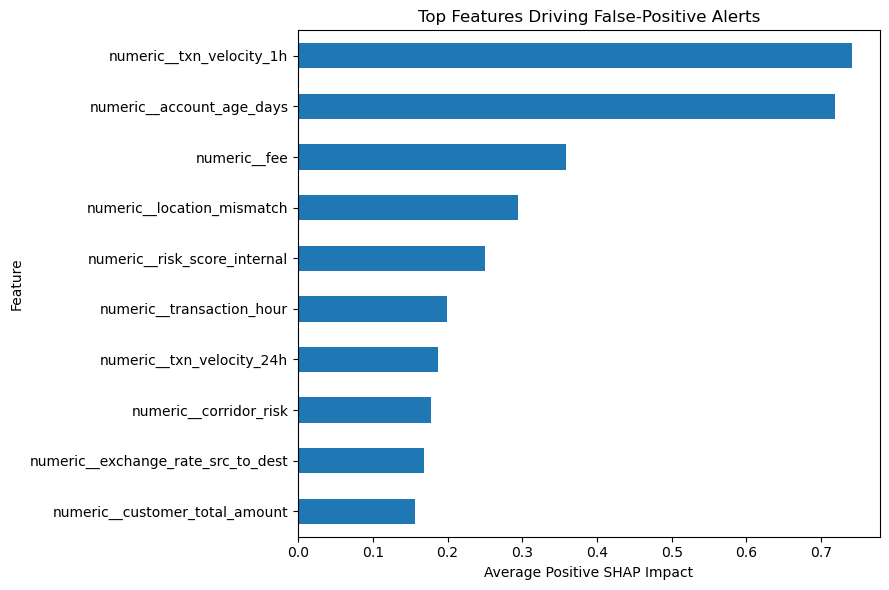

In [211]:
top_false_positive_drivers = (
    false_positive_drivers
    .head(10)
    .sort_values(
        "average_positive_shap"
    )
)

top_false_positive_drivers.plot(
    x="feature",
    y="average_positive_shap",
    kind="barh",
    legend=False,
    figsize=(9, 6),
    title="Top Features Driving False-Positive Alerts"
)

plt.xlabel("Average Positive SHAP Impact")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Observation

The chart shows which features most often pushed legitimate transactions towards a fraud classification.

These features may create false positives when genuine customer behaviour resembles patterns previously associated with fraud.

## 16. Select a False Positive for Local Explanation

### What problem is being solved?

A legitimate transaction with a high fraud-confidence score will be selected.

This provides a clear example of why the model may confidently make an incorrect prediction.

In [212]:
selected_transaction_index = (
    false_positive_review[
        "fraud_confidence"
    ].idxmax()
)

selected_test_position = (
    X_test.index.get_loc(
        selected_transaction_index
    )
)

selected_confidence = (
    test_probabilities[
        selected_test_position
    ]
)

selected_transaction_details = (
    feature_df.loc[
        selected_transaction_index,
        [
            "transaction_id",
            "customer_id",
            "amount_usd",
            "transfer_corridor",
            "time_of_day",
            "transaction_weekday",
            "channel",
            "kyc_tier",
            "is_fraud"
        ]
    ]
)

print(
    "Fraud-confidence score:",
    round(selected_confidence, 4)
)

selected_transaction_details

Fraud-confidence score: 0.9746


transaction_id         1daa0060-79b6-46bd-a764-53252645b817
customer_id            7041b9c1-3719-4ca8-9a6b-811b47cea6c0
amount_usd                                           263.29
transfer_corridor                                GBP_to_USD
time_of_day                                       afternoon
transaction_weekday                               Wednesday
channel                                                 web
kyc_tier                                           standard
is_fraud                                                  0
Name: 5792, dtype: object

### Observation

A legitimate transaction with a high fraud-confidence score was selected for detailed review.

Although the known label is legitimate, the model identified patterns that strongly resembled the fraud examples learned during training.

## 17. Create a Local SHAP Explanation

### What problem is being solved?

A local SHAP explanation will show how individual features increased or reduced the fraud score for the selected transaction.

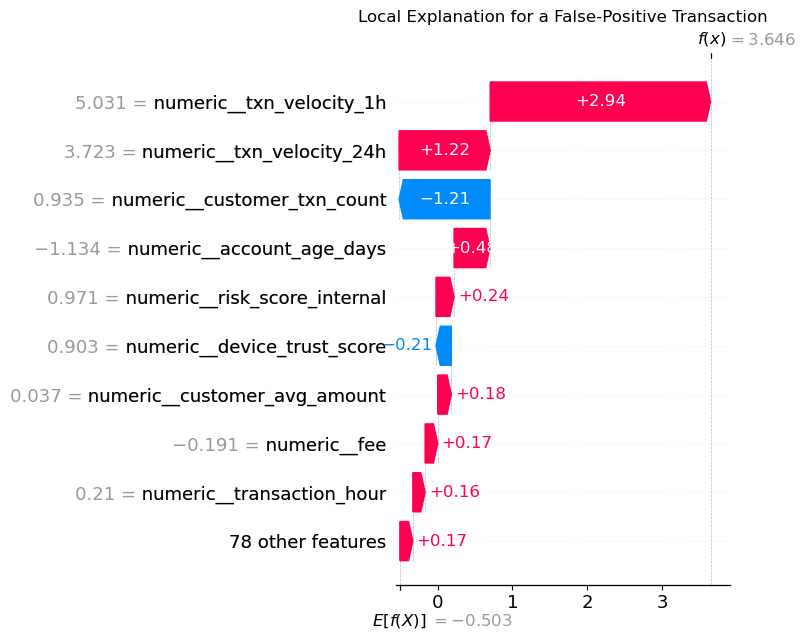

In [213]:
selected_processed_transaction = (
    X_test_processed.loc[
        [selected_transaction_index]
    ]
)

local_explanation = shap_explainer(
    selected_processed_transaction
)

local_explanation_for_plot = (
    local_explanation[0]
)

if local_explanation.values.ndim == 3:
    local_explanation_for_plot = (
        local_explanation[0, :, 1]
    )

shap.plots.waterfall(
    local_explanation_for_plot,
    max_display=10,
    show=False
)

plt.title(
    "Local Explanation for a False-Positive Transaction"
)

plt.tight_layout()
plt.show()

### Observation

The SHAP waterfall chart explains why the selected legitimate transaction was flagged as fraud.

Features pushing the prediction towards fraud increased the model score, while features pushing towards legitimacy reduced it.

The final combination of these feature contributions caused the model to classify the transaction as fraudulent.

## 18. Create Transaction-Level Reason Codes

### What problem is being solved?

Fraud analysts and stakeholders need short, understandable reasons rather than raw SHAP values.

The strongest positive feature contributions will be converted into reason codes.

In [214]:
local_shap_values = (
    local_explanation.values
)

if local_shap_values.ndim == 3:
    local_shap_values = (
        local_shap_values[:, :, 1]
    )

local_shap_values = (
    local_shap_values[0]
)

def clean_feature_name(feature):
    cleaned = feature.replace(
        "numeric__",
        ""
    )

    cleaned = cleaned.replace(
        "categorical__",
        ""
    )

    cleaned = cleaned.replace(
        "_",
        " "
    )

    return cleaned.title()

local_reason_table = pd.DataFrame({
    "feature": selected_processed_transaction.columns,
    "shap_impact": local_shap_values
})

local_reason_table["reason_code"] = (
    local_reason_table["feature"]
    .apply(clean_feature_name)
)

local_reason_table["direction"] = np.where(
    local_reason_table["shap_impact"] > 0,
    "Increased fraud score",
    "Reduced fraud score"
)

local_reason_table["absolute_impact"] = (
    local_reason_table["shap_impact"]
    .abs()
)

top_local_reasons = (
    local_reason_table[
        local_reason_table[
            "shap_impact"
        ] > 0
    ]
    .sort_values(
        "absolute_impact",
        ascending=False
    )
    .head(5)
)

top_local_reasons[
    [
        "reason_code",
        "direction",
        "shap_impact"
    ]
]

,reason_code,direction,shap_impact
11,Txn Velocity 1H,Increased fraud score,2.942739
12,Txn Velocity 24H,Increased fraud score,1.216502
7,Account Age Days,Increased fraud score,0.479483
10,Risk Score Internal,Increased fraud score,0.241390
17,Customer Avg Amount,Increased fraud score,0.182245


### Observation

The strongest positive SHAP contributions were converted into understandable transaction-level reason codes.

These reason codes show the main factors that pushed the selected legitimate transaction towards a fraud prediction.

The reason codes do not prove that fraud occurred. They explain the patterns that influenced the model's decision and should support, rather than replace, analyst judgement.

## 19. Create the Stakeholder Review Record

### What problem is being solved?

Fraud analysts need a clear summary of the transaction, model decision, confidence score and main reason codes.

A structured review record will be created for the selected false-positive transaction.

In [215]:
reason_codes = (
    top_local_reasons["reason_code"]
    .tolist()
)

while len(reason_codes) < 3:
    reason_codes.append(
        "No additional reason identified"
    )

review_record = pd.DataFrame({
    "Transaction ID": [
        selected_transaction_details[
            "transaction_id"
        ]
    ],
    "Customer ID": [
        selected_transaction_details[
            "customer_id"
        ]
    ],
    "Actual Outcome": [
        "Legitimate"
    ],
    "Model Prediction": [
        "Fraud"
    ],
    "Fraud Confidence (%)": [
        round(
            selected_confidence * 100,
            2
        )
    ],
    "Top Reason 1": [
        reason_codes[0]
    ],
    "Top Reason 2": [
        reason_codes[1]
    ],
    "Top Reason 3": [
        reason_codes[2]
    ]
})

review_record

,Transaction ID,Customer ID,Actual Outcome,Model Prediction,Fraud Confidence (%),Top Reason 1,Top Reason 2,Top Reason 3
0,1daa0060-79b6-46bd-a764-53252645b817,7041b9c1-3719-4ca8-9a6b-811b47cea6c0,Legitimate,Fraud,97.46,Txn Velocity 1H,Txn Velocity 24H,Account Age Days


### Observation

The stakeholder review record summarises the model decision in a clear and accessible format.

It shows that the transaction was genuinely legitimate but was predicted as fraud, making it a false positive.

The confidence score and reason codes provide evidence that an analyst can review before making a final decision.

## 20. Generate a Plain-Language Explanation

### What problem is being solved?

Stakeholders may not understand SHAP values or technical feature names.

A plain-language explanation will describe why the transaction was flagged without using complex machine-learning terminology.

In [216]:
reason_summary = ", ".join(
    reason_codes[:3]
)

stakeholder_explanation = f"""
The transaction was flagged because its activity showed patterns associated with fraud, particularly {reason_summary}.

The model assigned a fraud-confidence score of {selected_confidence * 100:.2f}%.

However, the confirmed outcome shows that the transaction was legitimate. This means the alert was a false positive.

The model did not find proof of fraud. It identified a combination of risk patterns that resembled previous fraudulent transactions.

An analyst should review the customer's transaction history, identity checks and supporting context before deciding whether to block or release the transaction.
"""

print(stakeholder_explanation)


The transaction was flagged because its activity showed patterns associated with fraud, particularly Txn Velocity 1H, Txn Velocity 24H, Account Age Days.

The model assigned a fraud-confidence score of 97.46%.

However, the confirmed outcome shows that the transaction was legitimate. This means the alert was a false positive.

The model did not find proof of fraud. It identified a combination of risk patterns that resembled previous fraudulent transactions.

An analyst should review the customer's transaction history, identity checks and supporting context before deciding whether to block or release the transaction.



### Observation

The technical model output was converted into a clear stakeholder explanation.

The explanation distinguishes between a fraud-risk prediction and confirmed fraud.

This is important because model predictions should support analyst decisions rather than automatically determine that a customer committed fraud.

## 21. Create the Explanation Review Template

### What problem is being solved?

NovaPay requires a reusable review template that analysts can complete whenever a transaction is flagged.

The template will include transaction details, confidence, reason codes, analyst findings and final action.

In [217]:
reason_lines = "\n".join(
    f"- {reason}"
    for reason in reason_codes[:5]
)

template_text = f"""# NovaPay Fraud Alert Review Template

## 1. Transaction Details

- Transaction ID: {selected_transaction_details['transaction_id']}
- Customer ID: {selected_transaction_details['customer_id']}
- Transaction amount: ${selected_transaction_details['amount_usd']:.2f}
- Transfer corridor: {selected_transaction_details['transfer_corridor']}
- Transaction channel: {selected_transaction_details['channel']}
- Time of day: {selected_transaction_details['time_of_day']}
- Weekday: {selected_transaction_details['transaction_weekday']}
- KYC tier: {selected_transaction_details['kyc_tier']}

## 2. Model Decision

- Model: {selected_experiment['model']}
- Imbalance method: {selected_experiment['imbalance_method']}
- Prediction: Fraud
- Fraud-confidence score: {selected_confidence * 100:.2f}%
- Confirmed outcome: Legitimate
- Review type: False positive

## 3. Main Reason Codes

{reason_lines}

## 4. Analyst Review

- Does the activity match the customer's normal behaviour?
- Is the transaction supported by verified customer information?
- Are the device and location details consistent with previous activity?
- Is there evidence of account takeover or unusual transaction velocity?
- Are any of the reason codes caused by missing or outdated information?

## 5. Analyst Findings

Write the analyst's findings here:

____________________________________________________________

____________________________________________________________

## 6. Final Decision

- [ ] Confirm fraud
- [ ] Release transaction
- [ ] Request additional verification
- [ ] Escalate for senior review

## 7. Recommended Action

Write the recommended action here:

____________________________________________________________

## 8. Review Information

- Analyst name:
- Review date:
- Case reference:
"""

with open(
    "07_explanation_template.md",
    "w",
    encoding="utf-8"
) as file:
    file.write(template_text)

print(
    "07_explanation_template.md created successfully."
)

07_explanation_template.md created successfully.


### Observation

The stakeholder explanation template was created successfully.

It includes the transaction details, fraud-confidence score, reason codes, analyst questions, findings and final decision.

This provides a consistent and regulator-friendly format for reviewing future fraud alerts.

## 22. Review the Main False-Positive Features

### Reflection question

Which features most often lead to false positives and why?

The five strongest false-positive drivers will be displayed in a simplified format.

In [218]:
top_false_positive_features = (
    false_positive_drivers
    .head(5)
    .copy()
)

top_false_positive_features[
    "readable_feature"
] = (
    top_false_positive_features[
        "feature"
    ]
    .apply(clean_feature_name)
)

top_false_positive_features[
    [
        "readable_feature",
        "average_positive_shap"
    ]
]

,readable_feature,average_positive_shap
0,Txn Velocity 1H,0.741611
1,Account Age Days,0.717985
2,Fee,0.358334
3,Location Mismatch,0.293999
4,Risk Score Internal,0.250441


### Observation

The displayed features were the strongest recurring drivers of false-positive alerts.

False positives can occur when legitimate activity resembles historical fraud behaviour. For example, a genuine customer may make several transactions quickly, use a higher-risk transfer corridor or complete a transaction from an unfamiliar location.

These features remain useful fraud indicators, but they should be interpreted with customer history and supporting context.

The model should not simply remove these features. Instead, NovaPay should review thresholds, improve customer-level context and monitor how often each feature contributes to incorrect alerts.

## 23. Scenario-Based Assessment

### Scenario

Explain to a stakeholder why a legitimate transaction was mistakenly flagged and how the model could be adjusted.

The response will use the selected false-positive transaction and its actual reason codes.

In [219]:
assessment_response = f"""
The transaction was mistakenly flagged because several of its characteristics resembled patterns previously associated with fraud.

The strongest reasons were {reason_summary}. Together, these features increased the model's fraud score to {selected_confidence * 100:.2f}%.

The transaction was later confirmed as legitimate, so the alert was a false positive. This does not necessarily mean that the model failed completely. It means the customer's genuine activity looked similar to activity found in past fraud cases.

I would not immediately remove the features because they may still be important fraud signals.

I would improve the model by reviewing the decision threshold, adding more customer-history context, analysing repeated false positives and retraining the model with recently reviewed cases.

For high-confidence alerts with conflicting customer evidence, I would also recommend analyst review or additional customer verification instead of an automatic block.
"""

print(assessment_response)


The transaction was mistakenly flagged because several of its characteristics resembled patterns previously associated with fraud.

The strongest reasons were Txn Velocity 1H, Txn Velocity 24H, Account Age Days. Together, these features increased the model's fraud score to 97.46%.

The transaction was later confirmed as legitimate, so the alert was a false positive. This does not necessarily mean that the model failed completely. It means the customer's genuine activity looked similar to activity found in past fraud cases.

I would not immediately remove the features because they may still be important fraud signals.

I would improve the model by reviewing the decision threshold, adding more customer-history context, analysing repeated false positives and retraining the model with recently reviewed cases.

For high-confidence alerts with conflicting customer evidence, I would also recommend analyst review or additional customer verification instead of an automatic block.



### Observation

The scenario response explains the false positive without claiming that the customer committed fraud.

It recommends threshold review, stronger customer context, feedback from reviewed alerts and human verification for uncertain cases.

This balances fraud prevention with the need to avoid unnecessary disruption to legitimate customers.

## 24. Confirm the Day 7 Explanation File

### What problem is being solved?

The explanation template must be confirmed before the Day 7 submission is prepared.

In [220]:
import os

if os.path.exists(
    "07_explanation_template.md"
):
    print(
        "07_explanation_template.md — FOUND"
    )
else:
    print(
        "07_explanation_template.md — NOT FOUND"
    )

07_explanation_template.md — FOUND


### Observation

The required stakeholder explanation template is available in the Jupyter folder.

It is ready to be included with the Day 7 notebook in the submission package.

# Day 7 Summary

## Main Findings

Day 7 focused on explaining the selected LightGBM fraud model and reviewing false-positive alerts.

SHAP was used to:

- identify the most influential model features;
- explain an individual fraud prediction;
- identify features contributing to false positives;
- convert technical feature impacts into understandable reason codes.

A legitimate transaction incorrectly flagged as fraud was selected for detailed analysis.

The local explanation showed how several features combined to increase its fraud-confidence score.

## Reflection

False positives often occur when legitimate customer behaviour resembles patterns found in historical fraud.

Features such as transaction velocity, risk scores, transfer corridor, location mismatch and unusual transaction values may be valid fraud indicators but can also occur during genuine customer activity.

These features should not automatically be removed. They should be supported by customer history, updated data, threshold monitoring and analyst review.

## Business Decision

The selected model should provide confidence scores and reason codes with every fraud alert.

High-risk transactions should be prioritised for review, while borderline cases should receive additional verification rather than automatic rejection.

Reviewed false positives should be recorded and used to improve future model training.

## 26. Generate the Day 7 Submission Text

The final submission text will be generated using the actual model, false-positive count and explanation results from the notebook.

In [222]:
submission_text = f"""Day 7 – Explainability & Stakeholder Review

I completed the Week 2 Day 2 explainability and stakeholder-review task using the selected LightGBM model with random undersampling.

The model was rebuilt using the same engineered dataset, preprocessing rules, model parameters and train-test split used during Day 6.

The rebuilt model achieved:

- Accuracy: {performance_result.loc[0, 'accuracy']:.4f}
- Precision: {performance_result.loc[0, 'precision']:.4f}
- Recall: {performance_result.loc[0, 'recall']:.4f}
- F1-score: {performance_result.loc[0, 'f1_score']:.4f}
- ROC-AUC: {performance_result.loc[0, 'roc_auc']:.4f}

SHAP was used to produce global and transaction-level explanations.

The global analysis identified the features that had the strongest overall influence on fraud predictions.

The false-positive review identified {len(false_positive_review)} legitimate transactions that were incorrectly flagged as fraud.

One high-confidence false positive was selected for detailed review. Its main reason codes included {reason_summary}.

A stakeholder review template was created containing:

- transaction details;
- model prediction;
- confidence score;
- main reason codes;
- analyst-review questions;
- final decision and recommended action.

Reflection:

False positives occur when legitimate behaviour resembles fraud patterns learned by the model. Important features should not be removed automatically because they may still detect genuine fraud.

The model can be improved by reviewing its decision threshold, adding more customer-history context, monitoring repeated false-positive drivers and retraining it with reviewed cases.

Business decision:

Fraud-confidence scores and reason codes should accompany every alert. Borderline cases should receive analyst review or additional verification rather than automatic rejection.
"""

print(submission_text)

Day 7 – Explainability & Stakeholder Review

I completed the Week 2 Day 2 explainability and stakeholder-review task using the selected LightGBM model with random undersampling.

The model was rebuilt using the same engineered dataset, preprocessing rules, model parameters and train-test split used during Day 6.

The rebuilt model achieved:

- Accuracy: 0.9704
- Precision: 0.8308
- Recall: 0.8392
- F1-score: 0.8350
- ROC-AUC: 0.9425

SHAP was used to produce global and transaction-level explanations.

The global analysis identified the features that had the strongest overall influence on fraud predictions.

The false-positive review identified 34 legitimate transactions that were incorrectly flagged as fraud.

One high-confidence false positive was selected for detailed review. Its main reason codes included Txn Velocity 1H, Txn Velocity 24H, Account Age Days.

A stakeholder review template was created containing:

- transaction details;
- model prediction;
- confidence score;
- main r

### Observation

The final Day 7 submission text was generated using the actual results from the explainability analysis.

This ensures that the submitted model metrics, false-positive count and explanation findings match the notebook outputs.